# The 25 ReEDS cases: 100% SMR deployment + traditional-build comparators

**What this notebook does.** The companion MC (`mc_cost_trajectories.ipynb`) already selects
and exports 18 ReEDS cases — but under winner-take-all, where some drawn futures resolve in
favor of large reactors and export a traditional build program. The mixed-build stress test
(`mixed_build_optimizer.ipynb`) then established that pure single-technology programs are
truly optimal, and the SMR program is the cheaper one in 76–89% of futures. The next phase of
the paper therefore **assumes the deployment mandate is met entirely with SMRs**, and this
notebook regenerates the 18 cases under that assumption:

1. re-run the companion notebook's own Monte Carlo — **the identical drawn worlds** (same
   draw code, same copula, same seed streams; asserted bit-for-bit against its per-draw
   export in QA-0) — with **SMRs receiving the entire build program** in every draw and
   large reactors riding the loser channel — international spillover plus the drawn
   cross-tech fraction x of the SMR program (the counterfactual cost ReEDS sees if it ever
   considers building one anyway);
2. select **three percentile joint draws per schedule** (v10, adopted 2026-08-06, reverting
   the 2026-08-03 designed-cases detour): the actual drawn worlds whose **program NPV** sits
   at P5/P50/P95 of the schedule's own 10,000-draw ranking, with registered draw indices
   (`exports/smr100/selected_draws.csv`). Read the selection as a **constrained optimizer**:
   the near-minimal / median / near-maximal program-NPV worlds over the *plausible* set —
   the drawn worlds, at the 90% level — rather than over the priors' support corners. The
   engine-optimized lo/hi bounds are **kept** as an appendix **possibility frontier** and as
   the dual-monotonicity **pilot instruments** (one schedule's pair exports separately), and
   the literature-expected world is demoted to a **zero-run overlay** on the figures and
   placement tables;
3. select the six **large100 comparator cases** (adopted 2026-08-10): `tech_comparison.ipynb`
   shows plausible drawn worlds where the traditional build is the cheaper program, so each
   schedule also gets one traditional-nuclear run at its **mid case** — the drawn world at
   P50 of the **pure-large** program-NPV ranking over the identical 10,000 worlds. Roles
   swap: large receives the entire program, SMRs ride the loser channel (international
   spillover + the drawn `x_ls` fraction). Conditional what-ifs, not winner claims;
4. export every selected case in ReEDS's own input formats (plant characteristics,
   financing/duration wiring, and the 24-case run matrix), round-trip-checked by the QA cells.
   The smr100 cases mandate **SMR capacity only** (`GSw_NuclearCapMandateTechScen=smr` with
   the `{scen}_smr` additions-basis trajectories, which equal this notebook's own program
   additions) — the large counterfactual can never fulfill the mandate, and it is never
   economic without it. The large100 comparators override per-case to a **large-only**
   mandate (`GSw_NuclearCapMandateTechScen=large` with the `{scen}_large` FLEET-INCLUSIVE
   trajectories: the existing 80-yr-license fleet path plus the same program additions —
   the mandate counts all vintages, so an additions basis would be absorbed by the
   existing fleet). Every run carries the **no-nuclear-ITC baseline**
   (`incentives_suffix=obbba_nonuclearitc`, adopted 2026-08-10): the OBBBA nuclear ITC
   (30%, online years through 2038) is zeroed so the mandate dual reads directly as the
   *total* required ITC; all other technologies' OBBBA credits are unchanged.

**Draw design:** verbatim the companion notebook's (S8 there) — one Gaussian copula joining
learning rate, anchor cost, and global deployment position, with both technologies at the
*same percentile* of their published ranges (comonotone; so the SMR is always the pricier,
faster-learning technology by construction). The mixed-build notebook's independent-draw
variant was a robustness device only; the paper's sample space is this one. The MC is again
what the cases are *drawn from*; the monotonicity and bounds sections below are the appendix
diagnostics that certify the possibility frontier and document why the designed-corner
detour was demoted.

**Discipline reminder:** every cost trajectory is conditional on its imposed deployment
schedule — these are "what would it cost if we built this much" curves, never predictions.

**Naming:** production cases are `smr100_{schedule}_{p05|p50|p95}` (e.g. `smr100_mck_p50`)
plus the comparators `large100_{schedule}_p50`, files `nuclear_mc_smr100_*` /
`nuclear_mc_large100_*` / `financials_tech_mc_*` etc., run matrix
`cases_nuclearlearning_smr100.csv` (25 columns: 18 smr100 + 6 large100 + the equality
flip copy `smr100_eia_p50_eq`, which shares all of `smr100_eia_p50`'s input files and
differs only in `GSw_NuclearCapMandate=2` — the issue-6 confirmation instrument). The pilot bounds
pair exports as `smr100_{sched}_{blo|bhi}` into the separate
`cases_nuclearlearning_smr100_bounds.csv`, so the production matrix stays 24 columns. Both sets are deliberately distinct from the earlier
winner-take-all export set (`*_mc_{sched}_{pct}`), which remains on disk until retired.

In [1]:
import json
import os
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
EXPORTS = NB_DIR / "exports" / "smr100"
FIGURES = NB_DIR / "figures"
for d in (EXPORTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

import sys
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

# --- Reproducibility: one master seed, independent named streams. The world streams use
# the COMPANION notebook's names ("world/{schedule}") so the drawn worlds here are
# bit-identical to mc_cost_trajectories.ipynb's (QA-0 asserts this); streams unique to
# this notebook are prefixed "smr100/". ---
MASTER_SEED = 20260715

def rng_stream(name):
    """An independent, reproducible random generator tied to a label."""
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- Analysis switches ---
COPULA_SET = "moderate"                # within-tech lr <-> boak correlation (as companions)
RANKING_FUNCTIONAL = "discounted_schedule_weighted_npv"  # issue-8 default weights, NPV cost object (2026-08-03)
# NOTE: deliberately differs from mc_cost_trajectories' financed-CAPEX ranking - the mc_ and
# smr100 case families' percentile labels are NOT on a common scale (see README).
N_DRAWS = int(os.environ.get("SMR100_DRAWS", 10000))  # per schedule; env override for test runs

# --- Model frame (identical to the companion notebooks) ---
YEARS = np.arange(2024, 2051)
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030
N_BOAK_UNITS = 2.0
OMEGA = 1.0 / 3.0
CES_RHO_GRID = np.array([-1.0, 0.0, 1.0])   # symmetric since 2026-08-06 (companion S1)
X_SPILL_MAX = 0.30     # cross-tech spillover fractions drawn U(0, X_SPILL_MAX) per direction
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0
U_GRID = np.linspace(0.0, 1.0, 21)

print(f"notebook dir : {NB_DIR}")
print(f"switches     : copula={COPULA_SET}, ranking={RANKING_FUNCTIONAL}, draws/schedule={N_DRAWS}")
print("deployment   : 100% SMR (large rides the loser channel: intl spillover + x * SMR program)")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
switches     : copula=moderate, ranking=discounted_schedule_weighted_npv, draws/schedule=10000
deployment   : 100% SMR (large rides the loser channel: intl spillover + x * SMR program)


## Ported foundations

Everything below is ported verbatim from the companion notebooks (see `mc_cost_trajectories.ipynb`
S2–S7 for the full plain-language walkthroughs): the six schedules from the single-source-of-truth
CSV, the PRIS-based historical and international experience stocks, the learning-curve engine,
the INL construction-duration model, and the ReEDS financing replication.

In [2]:
US_GW_2024 = 97.0
OFFSET_GW = 3.0

US_SCHEDULES_CSV = REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"
_sched_df = pd.read_csv(US_SCHEDULES_CSV, comment="#", index_col="year")
TOKEN_NAME = {"eia_aeo_high": "EIA 2026 AEO high", "abou_jaoude": "Abou-Jaoude mod",
              "iaea_high": "IAEA high", "mckinsey": "McKinsey GEP 2025",
              "cop28": "COP28 tripling pledge", "eo2025": "2025 EO"}
assert set(_sched_df.columns) == set(TOKEN_NAME), "US_SCHEDULES.csv columns changed"
assert list(_sched_df.index) == list(YEARS), "US_SCHEDULES.csv year grid changed"
US_SCHEDULES = {TOKEN_NAME[tok]: _sched_df[tok].to_numpy(float) for tok in TOKEN_NAME}
SCHED_ORDER = list(US_SCHEDULES)
SCEN_TOKEN = {v: k for k, v in TOKEN_NAME.items()}

REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues
FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2030   # pipeline's real visibility horizon; structurally zero after 2030 (mc S3)
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}
# Under-construction units are excluded: 5 carry PLANNED grid dates (not completed experience)
_ever = PRIS_UNITS[(PRIS_UNITS["status"] != "under construction")
                   & PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}
US_LICENSE_LIFE = 80.0
ONE_FACTOR_DELTA = 0.0

def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through PIPE_END = 2030 (real units; structurally
    zero after 2030, so it only shapes the pre-anchor record - see mc_cost_trajectories S3)."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 65.0 + 5.0*u)   # IAEA-calibrated lives, 65+5u (mc S3; 2026-08-05)
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

# Foreign stocks on the u grid (companion S3): unsplit, 1-GW basis - the engine's cross-firm
# channel does not distinguish designs (companion S5 Step 5). The IAEA SMR-share split of the
# foreign fleet lives in the main notebook's S14 own-routing sensitivity, not in any engine.
REGION_STOCK = {}
for r in REGIONS:
    m_a = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        flow = gross_additions_gw(r, u)
        flow = flow.copy(); flow[YEARS <= ANCHOR] = 0.0
        m_a[gi] = np.cumsum(flow) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m_a

# US gross GW added per year under each schedule (post-anchor), and the program unit
# counts under 100%-SMR (N_US_SMR) and 100%-large (N_US_LARGE, the large100 comparators)
# builds. ZEROS_T is the loser tech's (international-only) channel in either direction.
US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)
GW_ADD, N_US_SMR, N_US_LARGE = {}, {}, {}
for name in SCHED_ORDER:
    cap = US_SCHEDULES[name] - OFFSET_GW
    dnet = np.diff(cap, prepend=cap[0])
    flow = np.clip(dnet + US_RET, 0.0, None)
    flow[YEARS <= ANCHOR] = 0.0
    GW_ADD[name] = flow
    N_US_SMR[name] = np.cumsum(flow) / TECH["smr"]["unit_gw"]
    N_US_LARGE[name] = np.cumsum(flow) / TECH["large"]["unit_gw"]
ZEROS_T = np.zeros(T)

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction")
print("SMR units by 2050 under 100%-SMR deployment, per schedule:")
for name in SCHED_ORDER:
    print(f"  {name:22s} {N_US_SMR[name][-1]:6.0f} SMR units ({GW_ADD[name].sum():.0f} GW)")

PRIS fleet loaded: 417 operational, 62 under construction
SMR units by 2050 under 100%-SMR deployment, per schedule:
  EIA 2026 AEO high          69 SMR units (21 GW)
  Abou-Jaoude mod           121 SMR units (36 GW)
  IAEA high                 252 SMR units (76 GW)
  McKinsey GEP 2025         345 SMR units (103 GW)
  COP28 tripling pledge     678 SMR units (203 GW)
  2025 EO                  1011 SMR units (303 GW)


In [3]:
# The OCC engine — verbatim companion port (mc_cost_trajectories.ipynb S5).
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)

def lag1(a):
    """One-year completion lag along the time axis: the stock ENTERING year t is the builds
    completed through t-1. Cumulative arrays stay end-of-year for accounting; the lag is
    applied here, at the pricing boundary - without it the first post-anchor cohort would
    price on its own not-yet-built units (below BOAK). Companion-identical (mc S5)."""
    a = np.asarray(a, float)
    out = np.zeros_like(a)
    out[..., 1:] = a[..., :-1]
    return out

OTHER_TECH = {"large": "smr", "smr": "large"}
X_IN_COL = {"large": "x_sl", "smr": "x_ls"}     # incoming cross-tech fraction, per receiving tech

def experience_channels(world, tech, n_us, n_oth=None):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).
    Companion-identical (mc S5): international experience enters the CROSS-FIRM channel at
    weight s*theta, unsplit across technologies (the K&V flows are normalized to the
    domestic inter-firm citation baseline - omega prices the firm wall, theta the border);
    the drawn incoming x scales the other tech's US program (n_oth) into the same channel."""
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_kv = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_kv += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    S_kv = lag1(S_kv)                                    # stock entering year t (built thru t-1)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0    # D8': US LWR history -> large only
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + S_kv)
    if n_oth is not None:                                # cross-tech: x * the other tech's program
        x = world[X_IN_COL[tech]].values[:, None]
        oth = oth + x*lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))
    return own, oth

CES_EPS = 1e-8

def occ_paths_ces(world, tech, n_us, n_oth=None, ces_rho=None):
    """Production OCC engine (companion D11/D12, verbatim). Returns $/kW (2022 USD)."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def percentile_table(paths, ps=(5, 25, 50, 75, 95)):
    """Yearly percentiles of a (n_draws, T) trajectory array."""
    return pd.DataFrame({f"P{p}": np.percentile(paths, p, axis=0) for p in ps}, index=YEARS)

In [4]:
# Durations + ReEDS financing — verbatim companion ports (S6-S7 there).
DUR_UNITS = pl.duration_panel(PRIS_UNITS)
DUR_UNITS = DUR_UNITS[DUR_UNITS["family"].isin(["AP1000", "APR1400", "HPR1000"])].reset_index(drop=True)
DUR_UNITS = DUR_UNITS.rename(columns={"reactor_name": "unit"})

def fit_family_fe(df):
    """ln(duration) = family intercepts + b*ln(family sequence); returns (coefficients, residual sd)."""
    X = np.column_stack([np.ones(len(df)),
                         (df["family"] == "APR1400").astype(float),
                         (df["family"] == "HPR1000").astype(float),
                         np.log(df["family_seq"].astype(float))])
    Y = np.log(df["months"].values)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ beta
    return beta, resid.std(ddof=min(4, len(df)-1))

beta_hat, sig_hat = fit_family_fe(DUR_UNITS)

INL_DUR_MOD = np.array([118.0, 88.0, 74.0, 67.0, 62.0, 59.0, 56.0, 54.0, 52.0, 50.0])
INL_DUR_OPT = np.array([118.0, 70.0, 57.0, 49.0, 45.0, 42.0, 40.0, 38.0, 37.0, 36.0])
SMR_DUR_RATIO = 55.0/82.0
SMR_DUR_FLOOR = 43.0

def duration_paths(world, tech, n_us):
    """Construction duration (months, FNC -> COD) per draw-year, from the INL series curves."""
    n = len(world)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))   # completed units only
    n_own = N_us / world["n_vendors"].values[:, None]
    series = np.clip(2 + np.floor(n_own/2.0).astype(int), 2, len(INL_DUR_MOD))
    opt, mod = np.take(INL_DUR_OPT, series-1), np.take(INL_DUR_MOD, series-1)
    base = opt + world["dur_lambda"].values[:, None]*(mod - opt)
    if tech == "smr":
        base = np.maximum(base * SMR_DUR_RATIO, SMR_DUR_FLOOR)
    return base * np.exp(world["dur_z"].values[:, None]*sig_hat)

FIN_DIR = REPO_ROOT / "inputs" / "financials"

def load_reeds_financials():
    """ReEDS financial inputs on the YEARS grid, exactly as reeds/financials.py derives them."""
    sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
    infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
    sys_fin = sys_fin.merge(infl, on="t", how="left")
    sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                        + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                          * (1 - sys_fin["tax_rate"]) + 1)
    sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
    tech_fin = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
    tech_fin = tech_fin[tech_fin["i"].isin(["Nuclear", "Nuclear-SMR"])]
    dep = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
    cs = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")

    def on_years(col):
        s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
        return s.loc[YEARS].to_numpy(float)

    out = {"interest_base": on_years("interest_rate_nom"), "tax_rate": on_years("tax_rate"),
           "d_nom": on_years("d_nom"), "d_real": on_years("d_real"),
           "pv_dep": {}, "risk_mult": {}, "eval_adj": {}, "sched": {}}
    SYS_EVAL_YEARS = 30
    sys_pvf_sum = (1 - (1/out["d_real"])**(SYS_EVAL_YEARS - 1)) / (out["d_real"] - 1.0) + 1
    REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
    for tech, iname in REEDS_TECH_NAME.items():
        row = tech_fin[tech_fin["i"] == iname].iloc[-1]
        dep_frac = dep[str(int(row["depreciation_sch"]))].to_numpy(float)
        out["pv_dep"][tech] = np.array([np.sum(dep_frac / dn**np.arange(1, 22))
                                        for dn in out["d_nom"]])
        eval_p = float(row["eval_period"])
        out["risk_mult"][tech] = 1.0 + float(row["finance_diff_real"]) * (
            (1 - (1/out["d_real"])**eval_p) / (out["d_real"] - 1.0))
        tech_pvf_sum = (1 - (1/out["d_real"])**(eval_p - 1)) / (out["d_real"] - 1.0) + 1
        out["eval_adj"][tech] = sys_pvf_sum / tech_pvf_sum
        frac = pd.to_numeric(cs[str(row["construction_sch"])], errors="coerce").fillna(0.0).to_numpy()
        nz = np.flatnonzero(frac > 0)
        assert nz.size and nz[-1] - nz[0] + 1 == nz.size, \
            f"{iname}: spend profile has interior zeros; frac[frac>0] would shift spend years"
        out["sched"][tech] = frac[nz[0]:nz[-1] + 1]
    return out

FIN = load_reeds_financials()

def _resample_schedule(frac, n_years):
    """Stretch/compress a spend-fraction profile to `n_years` bins (sum to 1)."""
    frac = np.asarray(frac, float)
    n0 = len(frac)
    if n_years == n0:
        return frac / frac.sum()
    cdf = np.concatenate([[0.0], np.cumsum(frac)])
    xq = np.linspace(0.0, 1.0, n_years + 1)
    cdf_q = np.interp(xq, np.linspace(0.0, 1.0, n0 + 1), cdf)
    new = np.diff(cdf_q)
    return new / new.sum()

def ccmult_from_duration(duration_mo, interest_base, canonical_frac):
    """Construction-financing (IDC) multiplier for a learned duration (verbatim ReEDS port)."""
    n_years = int(round(duration_mo / 12.0))
    n_years = max(1, min(n_years, 10))
    x = _resample_schedule(canonical_frac, n_years)
    exps = np.arange(n_years) + 0.5
    return 1.0 + float(np.sum(x * (interest_base ** exps - 1.0)))

def ccmult_grid(dur_months, tech):
    """Vectorized ccmult for a (n_draws, T) duration array."""
    ib = FIN["interest_base"]
    table = np.empty((10 + 1, T))
    for n in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], n)
        exps = np.arange(n) + 0.5
        table[n] = 1.0 + (x[:, None] * (ib[None, :] ** exps[:, None] - 1.0)).sum(axis=0)
    n_years = np.clip(np.round(np.asarray(dur_months)/12.0).astype(int), 1, 10)
    return table[n_years, np.arange(T)[None, :]]

def fin_mult_rest(tech, use_itc=False):
    """Everything in ReEDS's cost_cap_fin_mult EXCEPT ccmult, per year (T,) — verbatim port."""
    assert not use_itc, "ITC variant deliberately not implemented"
    tax, pv_dep = FIN["tax_rate"], FIN["pv_dep"][tech]
    return (1.0/(1.0 - tax)) * (1.0 - tax*pv_dep) * FIN["risk_mult"][tech] * FIN["eval_adj"][tech]

FIN_REST = {tech: fin_mult_rest(tech) for tech in TECH}
DISC = np.cumprod(np.where(YEARS > ANCHOR, FIN["d_real"], 1.0))   # discount to 2030
print(f"foundations loaded: duration panel {len(DUR_UNITS)} units (sd {sig_hat:.3f}); "
      f"ccmult(72mo, 8%, '6') = {ccmult_from_duration(72.0, 1.08, FIN['sched']['large']):.6f}")

foundations loaded: duration panel 21 units (sd 0.116); ccmult(72mo, 8%, '6') = 1.268124


## The draw and the six Monte Carlos

The draw is the companion notebook's, **verbatim** (see its S4/S8 for the full rationale): one
Gaussian copula joins the three latent uncertainty axes — learning rate, 2030 anchor cost, and
global deployment position `u` — with learning rate and anchor cost modestly negatively
correlated under the default "moderate" set. Both technologies sit at the *same percentile* of
their published ranges within a draw, so the SMR is always the more expensive, faster-learning
technology by construction. The remaining inputs (international spillover scale `s`, vendor
count, tiny-base/full-stock convention, CES substitution parameter, two duration inputs) are
independent draws. Same code + same seed streams = **the identical worlds the companion
notebook analyzed** (QA-0 asserts this bit-for-bit).

For each schedule we then compute, for every draw:

- the **SMR full-program path**: overnight cost, construction duration, IDC multiplier, and
  financed capital cost with the entire schedule feeding SMR experience;
- the **large-reactor counterfactual path**: the same quantities with *zero* US large builds —
  its cost falls through international spillover plus the drawn cross-tech fraction x of the
  SMR program (companion S5 Step 5′). This is what ReEDS will see as the price of large
  nuclear if it ever considers it.

In [5]:
# Ported verbatim from mc_cost_trajectories.ipynb S8.
RHO_SETS = {"zero": 0.0, "moderate": -0.3, "strong": -0.6}
LATENTS = ["lr", "boak", "u"]

def corr_matrix(rho_key):
    C = np.eye(3)
    C[0, 1] = C[1, 0] = RHO_SETS[rho_key]
    ev = np.linalg.eigvalsh(C)
    assert ev.min() > 1e-10, f"correlation matrix '{rho_key}' is not positive definite: {ev}"
    return C

def draw_world(n, rho_key, rng):
    """Draw n worlds: every uncertain input, one row per draw (companion S8, verbatim)."""
    Z = rng.standard_normal((n, 3)) @ np.linalg.cholesky(corr_matrix(rho_key)).T
    U = stats.norm.cdf(Z)                                   # Gaussian copula -> uniforms
    w = pd.DataFrame(index=range(n))
    for tech in TECH:
        t = TECH[tech]
        w[f"lr_{tech}"] = t["lr_lo"] + U[:, 0]*(t["lr_hi"] - t["lr_lo"])      # comonotone across techs
        w[f"boak_{tech}"] = t["boak_lo"] + U[:, 1]*(t["boak_hi"] - t["boak_lo"])
    w["u"] = U[:, 2]                                        # global deployment position
    w["s"] = rng.uniform(0.0, 1.0, n)                       # spillover scale
    w["n_vendors"] = rng.integers(4, 9, n)                  # vendor count m
    w["conv_full"] = rng.integers(0, 2, n)                  # 0 = tiny-base, 1 = full-stock
    w["ces_rho"] = rng.choice(CES_RHO_GRID, size=n)         # channel-substitution stratum
    w["dur_lambda"] = rng.uniform(0.0, 1.0, n)              # duration scenario position
    w["dur_z"] = rng.standard_normal(n)                     # persistent duration project noise
    w["x_ls"] = rng.uniform(0.0, X_SPILL_MAX, n)            # cross-tech spillover: large -> SMR
    w["x_sl"] = rng.uniform(0.0, X_SPILL_MAX, n)            # cross-tech spillover: SMR -> large
    return w

WORLDS, results = {}, {}
for sched in SCHED_ORDER:
    # The COMPANION's stream names, deliberately: identical worlds to mc_cost_trajectories.ipynb
    world = draw_world(N_DRAWS, COPULA_SET, rng_stream(f"world/{SCEN_TOKEN[sched]}"))
    WORLDS[sched] = world
    r = {}
    for tech, n_us, n_oth in (("smr", N_US_SMR[sched], None),
                              ("large", ZEROS_T, N_US_SMR[sched])):   # loser: x * SMR program
        r[f"occ_{tech}"] = occ_paths_ces(world, tech, n_us, n_oth=n_oth)
        r[f"dur_{tech}"] = duration_paths(world, tech, n_us)
        r[f"ccmult_{tech}"] = ccmult_grid(r[f"dur_{tech}"], tech)
        r[f"fincapex_{tech}"] = r[f"occ_{tech}"] * r[f"ccmult_{tech}"] * FIN_REST[tech][None, :]
    results[sched] = r

print(f"drew {N_DRAWS} worlds x {len(SCHED_ORDER)} schedules (companion draw, comonotone)")
print("\n2050 SMR OCC and financed CAPEX by schedule ($/kW 2022, P5 / P50 / P95):")
for sched in SCHED_ORDER:
    o = results[sched]["occ_smr"][:, yi(2050)]
    f = results[sched]["fincapex_smr"][:, yi(2050)]
    print(f"  {sched:22s} OCC {np.percentile(o,5):5,.0f} /{np.percentile(o,50):6,.0f} /"
          f"{np.percentile(o,95):6,.0f}   financed {np.percentile(f,5):5,.0f} /"
          f"{np.percentile(f,50):6,.0f} /{np.percentile(f,95):6,.0f}")

drew 10000 worlds x 6 schedules (companion draw, comonotone)

2050 SMR OCC and financed CAPEX by schedule ($/kW 2022, P5 / P50 / P95):
  EIA 2026 AEO high      OCC 3,480 / 5,494 / 8,151   financed 4,597 / 7,280 /10,831
  Abou-Jaoude mod        OCC 3,101 / 5,110 / 7,897   financed 4,114 / 6,779 /10,432
  IAEA high              OCC 2,506 / 4,493 / 7,441   financed 3,307 / 5,967 / 9,878
  McKinsey GEP 2025      OCC 2,304 / 4,291 / 7,277   financed 3,067 / 5,705 / 9,681
  COP28 tripling pledge  OCC 1,891 / 3,779 / 6,890   financed 2,505 / 5,016 / 9,134
  2025 EO                OCC 1,693 / 3,483 / 6,610   financed 2,251 / 4,615 / 8,776


## The cost object: the program-NPV ranking

Every diagnostic, bound, and placement below is measured on one scalar per drawn world: the
**discounted, GW-weighted NPV of the SMR program** — financed CAPEX **plus the 30-year PV of
FOM, VOM, and fuel** (adopted 2026-08-03). The non-CAPEX side follows the O&M convention
validated in `npv_winner_check.ipynb`: FOM and VOM sit at the draw's own cost percentile
across the ATB 2024 advanced→conservative range (comonotone with the anchor cost — an
expensive-anchor world is also an expensive-O&M world), the capacity factor equals ReEDS's
own availability (≈0.904, identical for both techs by its prime-mover construction), and
fuel uses the AEO 2026 uranium price.

This ranking **selects the exported cases** (v10, 2026-08-06, restoring the percentile-draw
selection): the production cases are the joint draws at P5/P50/P95 of this scalar within
each schedule. It is also the measurement scale for everything else below: the OAT sweeps
and Monte Carlo cross-checks are computed on it, the appendix lo/hi possibility-frontier
bounds are optimized against it, and the literature-expected overlay's placement in the
drawn distribution is reported on it.

In [6]:
# --- Non-CAPEX costs for the NPV ranking (adopted 2026-08-03) ---
# All validation lives in npv_winner_check.ipynb: the winner survives the full NPV in >99%
# of draws, but WHICH draw sits nearest each P5/P50/P95 target moves -- so the selection
# here carries the full NPV. Convention: FOM and VOM sit at the same percentile of their
# ranges (ATB 2024 advanced -> conservative) as the draw's 2030 anchor cost does in its
# range -- comonotone with the cost dial, never independent sensitivities. CF equals ReEDS's
# own availability (avail, replicated bit-exactly from raw inputs in npv_winner_check N1);
# fuel is heat rate x AEO 2026 uranium; annual costs are levelized with ReEDS's
# pvf_onm = 1/crf (30-yr window at the system real rate).
PLANTCHAR_DIR = REPO_ROOT / "inputs" / "plant_characteristics"
EVAL_YEARS = 30
_d_real = float(DISC[-1] / DISC[-2])
_ks = np.arange(1, EVAL_YEARS + 1)
PVF_ONM = float((_d_real ** -_ks).sum())
assert round(1.0 / PVF_ONM, 5) == 0.06773   # ReEDS crf.csv pin (validated in npv_winner_check)

# CF: the avail number computed and QA'd by npv_winner_check.ipynb (national mean; identical
# for both techs by ReEDS's prime-mover construction)
_cf = pd.read_csv(NB_DIR / "exports" / "npv_winner_summary.csv")["CF"].unique()
assert len(_cf) == 1 and 0.89 < float(_cf[0]) < 0.92
CF_AVAIL = float(_cf[0])

_ATB_STEM = {"large": "nuclear", "smr": "nuclear-smr"}
OM_RANGE = {}
for tech in TECH:
    ends = {s: pd.read_csv(PLANTCHAR_DIR / f"{_ATB_STEM[tech]}_ATB_2024_{s}.csv")
                 .set_index("t").loc[2030]
            for s in ("advanced", "conservative")}
    # the ATB scenario axis IS the MC's anchor-cost axis -- one percentile indexes both
    assert (float(ends["advanced"]["capcost"]), float(ends["conservative"]["capcost"])) \
        == (TECH[tech]["boak_lo"], TECH[tech]["boak_hi"]), tech
    assert float(ends["advanced"]["heatrate"]) == float(ends["conservative"]["heatrate"])
    OM_RANGE[tech] = {
        "fom": (float(ends["advanced"]["fom"]), float(ends["conservative"]["fom"])),
        "vom": (float(ends["advanced"]["vom"]), float(ends["conservative"]["vom"])),
        "hr": float(ends["advanced"]["heatrate"]),
    }

def u1_of(world):
    """The draw's cost-dial percentile (shared by both techs -- comonotone)."""
    t = TECH["large"]
    return ((world["boak_large"] - t["boak_lo"]) / (t["boak_hi"] - t["boak_lo"])).to_numpy()

def om_at(tech, U1):
    """FOM ($/kW-yr) and VOM ($/MWh) at cost-dial percentile U1 (advanced -> conservative)."""
    lo_f, hi_f = OM_RANGE[tech]["fom"]
    lo_v, hi_v = OM_RANGE[tech]["vom"]
    return lo_f + U1 * (hi_f - lo_f), lo_v + U1 * (hi_v - lo_v)

# uranium AEO 2026 baseline: 2025$ -> 2022$, flat after 2050; per-build-year 30-yr fuel PV
_defl = pd.read_csv(REPO_ROOT / "inputs" / "financials" / "deflator.csv")
_defl.columns = ["year", "deflator"]
_defl = _defl.set_index("year")["deflator"]
_Pu = (pd.read_csv(REPO_ROOT / "inputs" / "fuelprices" / "uranium_AEO_2026_baseline.csv")
       .set_index("year")["cost"] * float(_defl.loc[2025] / _defl.loc[2022]))
_Pu = _Pu.reindex(range(int(YEARS.min()), int(YEARS.max()) + EVAL_YEARS + 1)).ffill()
MWH_PER_KWYR = 8.760 * CF_AVAIL                    # MWh generated per kW-yr at CF = avail
_FUEL_PV = {tech: MWH_PER_KWYR * OM_RANGE[tech]["hr"] * np.array(
    [(_Pu.loc[t + 1: t + EVAL_YEARS].to_numpy() * (_d_real ** -_ks)).sum() for t in YEARS])
    for tech in TECH}

def om_npv_per_kw(tech, U1):
    """(n, T) 30-yr PV per kW of capacity built in each year: FOM + VOM + fuel, 2022$."""
    fom, vom = om_at(tech, np.asarray(U1)[:, None])
    return PVF_ONM * (fom + MWH_PER_KWYR * vom) + _FUEL_PV[tech][None, :]

# the convention's check values (SMR at U1 = 0.75): boak $8,875/kW -> FOM $191.5, VOM $2.65
_f, _v = om_at("smr", 0.75)
assert (round(float(_f), 1), round(float(_v), 2)) == (191.5, 2.65)
print(f"NPV-ranking inputs: CF = avail = {CF_AVAIL:.4f} (npv_winner_check), "
      f"pvf_onm = 1/crf = {PVF_ONM:.4f};")
print("  FOM/VOM comonotone with the draw's cost percentile across ATB advanced->conservative;")
print("  30-yr PV of non-CAPEX per kW built 2031, at U1=0.5 ($/kW 2022): "
      f"large {om_npv_per_kw('large', np.array([0.5]))[0, yi(2031)]:,.0f}, "
      f"smr {om_npv_per_kw('smr', np.array([0.5]))[0, yi(2031)]:,.0f}")


NPV-ranking inputs: CF = avail = 0.9044 (npv_winner_check), pvf_onm = 1/crf = 14.7637;
  FOM/VOM comonotone with the draw's cost percentile across ATB advanced->conservative;
  30-yr PV of non-CAPEX per kW built 2031, at U1=0.5 ($/kW 2022): large 3,303, smr 3,245


In [7]:
SHORT = {"eia_aeo_high": "eia", "abou_jaoude": "aj", "iaea_high": "iaea",
         "mckinsey": "mck", "cop28": "cop28", "eo2025": "eo"}

def rank_smr(sched):
    """Program-NPV score per draw: discounted GW-weighted SMR financed CAPEX plus the 30-yr
    PV of FOM/VOM/fuel at the draw's own O&M percentile (lower = cheaper)."""
    w_t = GW_ADD[sched] / DISC
    npv = results[sched]["fincapex_smr"] + om_npv_per_kw("smr", u1_of(WORLDS[sched]))
    return npv @ w_t

print("cost object defined: rank_smr(sched) — the program-NPV scale every diagnostic, "
      "bound, and placement below is measured on")

cost object defined: rank_smr(sched) — the program-NPV scale every diagnostic, bound, and placement below is measured on


## Monotonicity: the bounds' validity certificate

The appendix **possibility-frontier bounds** below pin the certified-monotone inputs
(`U_lr`, `U_boak`, `dur_z`) at their cost-extreme ends and jointly enumerate the interacting
rest. That pinning is only valid if, for the program-NPV cost object:

1. **each pinned parameter's effect is monotone** across its drawn range (otherwise an
   interior value, not an end, is the extreme);
2. **the direction is the same in all six schedules** (one setting must serve all);
3. **the direction survives interactions**: a parameter's expensive end must not flip when
   the *other* parameters move to their extremes (checked by re-sweeping at both provisional
   corner worlds).

The first cell sweeps each parameter one-at-a-time through the exact engine and NPV score
the selection uses (`rank_smr`'s computation, on synthetic worlds), all other inputs pinned
at a central world, then re-checks direction stability at both provisional corners and
prints a verdict table plus the implied corner settings. The second cell cross-checks
against the Monte Carlo itself: mean score percentile by parameter decile — the *average*
effect over the joint distribution, interactions included, where the OAT sweep is the
*ceteris-paribus* effect at the center.

**Why the corner design was demoted (2026-08-06).** These diagnostics briefly justified
*replacing* the percentile draws with designed corner cases (2026-08-03). That design is
retired: the corner worlds sit at the priors' support endpoints — the least defensible
objects of the whole elicitation — and carry no probability mass, so the band they span is a
possibility statement with no probabilistic content. And the diagnosis that motivated the
detour cuts the other way on reflection: the "offsetting extremes" inside a percentile
joint draw are a *feature*, not a flaw — a world that is expensive overall while some inputs
sit at cheap values is exactly what a plausible expensive world looks like. This section is
kept as the validity certificate for the pinned directions the bounds use, and as the record
of why the corners were demoted to the appendix possibility frontier.

Note on the dials: `U_lr` and `U_boak` move both technologies comonotonically, exactly as
in the draw, and `U_boak` also carries FOM/VOM (the comonotone O&M convention). Setting the
two dials *independently* at their ends steps outside the copula's moderate −0.3 lr↔boak
correlation — fine for bounding worlds, but worth a sentence in the paper.

OAT verdict (curvature = max deviation from the endpoint chord, % of the swing):
           expensive_end  same_dir_all_scheds  monotone  max_nonmono_%  max_curvature_%  corner_stable  mc_spearman
param                                                                                                              
U_lr                 low                 True      True            0.0             10.0           True       -0.638
U_boak              high                 True      True            0.0              0.0           True        0.876
u                    low                 True      True            0.0              3.2           True       -0.004
s                    low                 True      True            0.0              7.9          False        0.029
x_ls                 low                False      True            0.0              0.0          False        0.005
x_sl                 low                False      True            0.0              0.0          False     

saved -> figures\smr100_oat_linearity.png


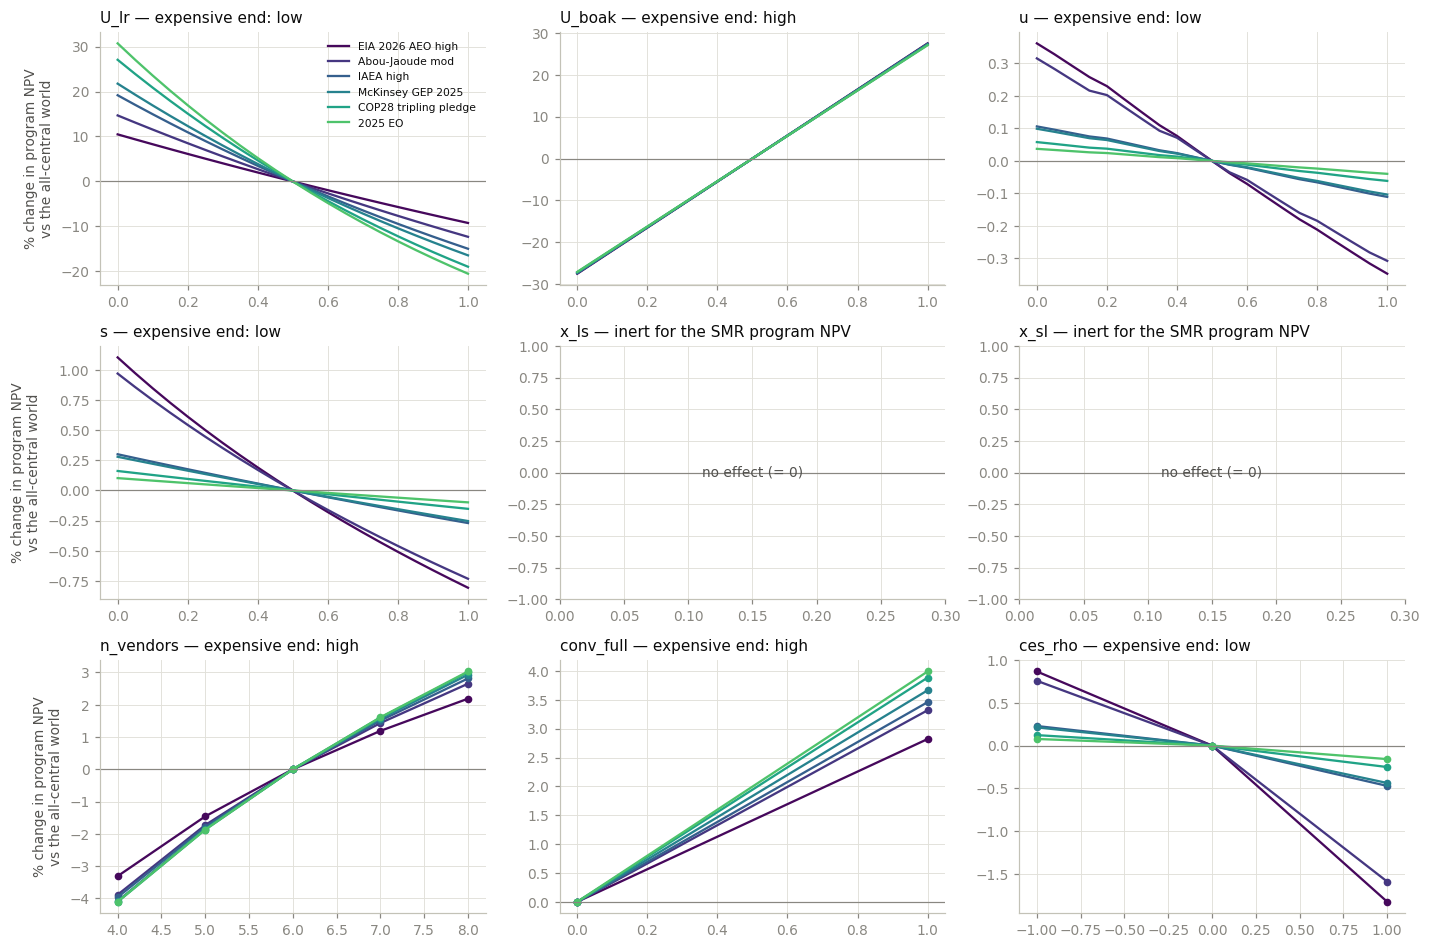

In [8]:
# --- OAT sweeps: each parameter's ceteris-paribus effect on the SMR program NPV ---
# Everything pinned at a central world; one parameter swept over its full drawn range; the
# score recomputed exactly as rank_smr() computes it. Then: direction consensus across
# schedules, monotonicity, curvature (max deviation from the endpoint chord), direction
# stability at the two provisional corner worlds, and Spearman agreement with the MC draws.
SWEEP_GRID = {
    "U_lr":       np.linspace(0.0, 1.0, 21),     # LR dial, both techs comonotone
    "U_boak":     np.linspace(0.0, 1.0, 21),     # anchor-cost dial (also FOM/VOM via U1)
    "u":          U_GRID.copy(),                 # global deployment position
    "s":          np.linspace(0.0, 1.0, 21),     # spillover scale
    "x_ls":       np.linspace(0.0, 0.30, 21),    # inert for the SMR NPV (no large program)
    "x_sl":       np.linspace(0.0, 0.30, 21),    # inert for the SMR NPV; prices the large
                                                 #   loser export only (designed-cases cell)
    "n_vendors":  np.arange(4, 9, dtype=float),  # vendor count m
    "conv_full":  np.array([0.0, 1.0]),          # tiny-base vs full-stock
    "ces_rho":    CES_RHO_GRID.copy(),           # channel-substitution stratum
    "dur_lambda": np.linspace(0.0, 1.0, 21),     # INL optimistic<->moderate position
    "dur_z":      np.linspace(-2.33, 2.33, 21),  # ~P1..P99 of the duration noise
}
DISCRETE = {"n_vendors", "conv_full", "ces_rho"}
BASE_WORLD = {"U_lr": 0.5, "U_boak": 0.5, "u": 0.5, "s": 0.5, "x_ls": 0.15, "x_sl": 0.15,
              "n_vendors": 6.0, "conv_full": 0.0, "ces_rho": 0.0, "dur_lambda": 0.5,
              "dur_z": 0.0}

def make_world(settings, n):
    """Synthetic world frame with every engine input pinned; dials expand to both techs."""
    w = pd.DataFrame(index=range(n))
    for tech in TECH:
        t = TECH[tech]
        w[f"lr_{tech}"] = t["lr_lo"] + np.asarray(settings["U_lr"], float)*(t["lr_hi"] - t["lr_lo"])
        w[f"boak_{tech}"] = t["boak_lo"] + np.asarray(settings["U_boak"], float)*(t["boak_hi"] - t["boak_lo"])
    for k in ("u", "s", "x_ls", "x_sl", "n_vendors", "conv_full", "ces_rho", "dur_lambda",
              "dur_z"):
        w[k] = np.asarray(settings[k], float)
    return w

def program_npv(world, sched):
    """rank_smr()'s score on an arbitrary world: same engine calls, same GW/DISC weights."""
    occ = occ_paths_ces(world, "smr", N_US_SMR[sched])
    dur = duration_paths(world, "smr", N_US_SMR[sched])
    npv = occ*ccmult_grid(dur, "smr")*FIN_REST["smr"][None, :] + om_npv_per_kw("smr", u1_of(world))
    return npv @ (GW_ADD[sched] / DISC)

def oat_sweep(param, base):
    grid = SWEEP_GRID[param]
    settings = {k: np.full(len(grid), v) for k, v in base.items()}
    settings[param] = grid
    w = make_world(settings, len(grid))
    return {sched: program_npv(w, sched) for sched in SCHED_ORDER}

sweeps = {p: oat_sweep(p, BASE_WORLD) for p in SWEEP_GRID}
base_score = {s: float(program_npv(make_world({k: [v] for k, v in BASE_WORLD.items()}, 1), s)[0])
              for s in SCHED_ORDER}
mc_score = {s: rank_smr(s) for s in SCHED_ORDER}

# direction: +1 = cost rises with the parameter (its HIGH end is the expensive end)
dir_by = {p: {s: np.sign(v[-1] - v[0]) for s, v in sw.items()} for p, sw in sweeps.items()}
consensus = {p: int(np.sign(sum(d.values()))) for p, d in dir_by.items()}

def corner_world(sign):
    """All parameters at their cost-min (sign=-1) or cost-max (+1) end per the consensus."""
    return {p: float(g[-1] if consensus[p] == sign else g[0]) for p, g in SWEEP_GRID.items()}

rows = []
for p, grid in SWEEP_GRID.items():
    same_dir = len(set(dir_by[p].values())) == 1
    mono_viol, curv = 0.0, 0.0
    for s, v in sweeps[p].items():
        swing = v[-1] - v[0]
        scale = max(abs(swing), 1e-4*abs(base_score[s]))     # guard for near-flat parameters
        mono_viol = max(mono_viol, float(-(np.diff(v)*consensus[p]).min() / scale))
        if p not in DISCRETE:
            chord = v[0] + swing*(grid - grid[0])/(grid[-1] - grid[0])
            curv = max(curv, float(np.abs(v - chord).max() / scale))
    stable = True
    for sign in (-1, +1):
        for s, v in oat_sweep(p, corner_world(sign)).items():
            if consensus[p]*(v[-1] - v[0]) < 0:
                stable = False
    col = {"U_lr": "lr_smr", "U_boak": "boak_smr"}.get(p, p)
    spear = float(np.mean([stats.spearmanr(WORLDS[s][col], mc_score[s])[0] for s in SCHED_ORDER]))
    rows.append({"param": p, "expensive_end": "high" if consensus[p] > 0 else "low",
                 "same_dir_all_scheds": same_dir, "monotone": mono_viol < 1e-3,
                 "max_nonmono_%": round(100*mono_viol, 2),
                 "max_curvature_%": None if p in DISCRETE else round(100*curv, 1),
                 "corner_stable": stable, "mc_spearman": round(spear, 3)})
verdict = pd.DataFrame(rows).set_index("param")
print("OAT verdict (curvature = max deviation from the endpoint chord, % of the swing):")
print(verdict.to_string())
_corners = pd.DataFrame({"cheap_corner (p05 candidate)": corner_world(-1),
                         "central (p50 candidate)": BASE_WORLD,
                         "expensive_corner (p95 candidate)": corner_world(+1)})
print("\nImplied designed worlds (dial units), pending the checks above:")
print(_corners.to_string())

import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import plotstyle as ps
ps.apply()

# schedule identity = the shared viridis ramp; SCHED_ORDER here carries display names,
# so map through SCEN_TOKEN/SHORT onto ps.SCHED_C's short tokens
SCHED_COLORS = {s: ps.SCHED_C[SHORT[SCEN_TOKEN[s]]] for s in SCHED_ORDER}
print("One-at-a-time sweeps of the SMR program NPV — all other inputs at the central world")
fig, axes = plt.subplots(3, 3, figsize=(ps.W3, 8.7))
for ax, (p, grid) in zip(axes.ravel(), SWEEP_GRID.items()):
    _ymax = max(float(np.abs(100.0*(sweeps[p][s]/base_score[s] - 1.0)).max())
                for s in SCHED_ORDER)
    if _ymax < 1e-9:
        # inert dials (x_ls, x_sl): the sweep is exactly zero up to float noise;
        # plotting the ~1e-14 residuals would fake a step response, so annotate instead
        ax.axhline(0.0, color=ps.FAINT, lw=0.8)
        ax.set_xlim(float(grid[0]), float(grid[-1]))
        ax.set_ylim(-1.0, 1.0)
        ax.text(0.5, 0.5, "no effect (= 0)", transform=ax.transAxes,
                ha="center", va="center", fontsize=9, color=ps.MUTED)
        ax.set_title(f"{p} — inert for the SMR program NPV")
        continue
    for s in SCHED_ORDER:
        y = 100.0*(sweeps[p][s]/base_score[s] - 1.0)
        ax.plot(grid, y, color=SCHED_COLORS[s], lw=1.5,
                marker="o" if p in DISCRETE else None, ms=4, label=s)
    ax.axhline(0.0, color=ps.FAINT, lw=0.8)
    ax.set_title(f"{p} — expensive end: {'high' if consensus[p] > 0 else 'low'}")
axes[0, 0].legend(fontsize=7)
for ax in axes[:, 0]:
    ax.set_ylabel("% change in program NPV\nvs the all-central world")
fig.tight_layout()
ps.savefig(fig, FIGURES / "smr100_oat_linearity.png")
plt.show()

Monte Carlo cross-check — mean score percentile by parameter decile (average effect, interactions included)


saved -> figures\smr100_mc_trend_check.png


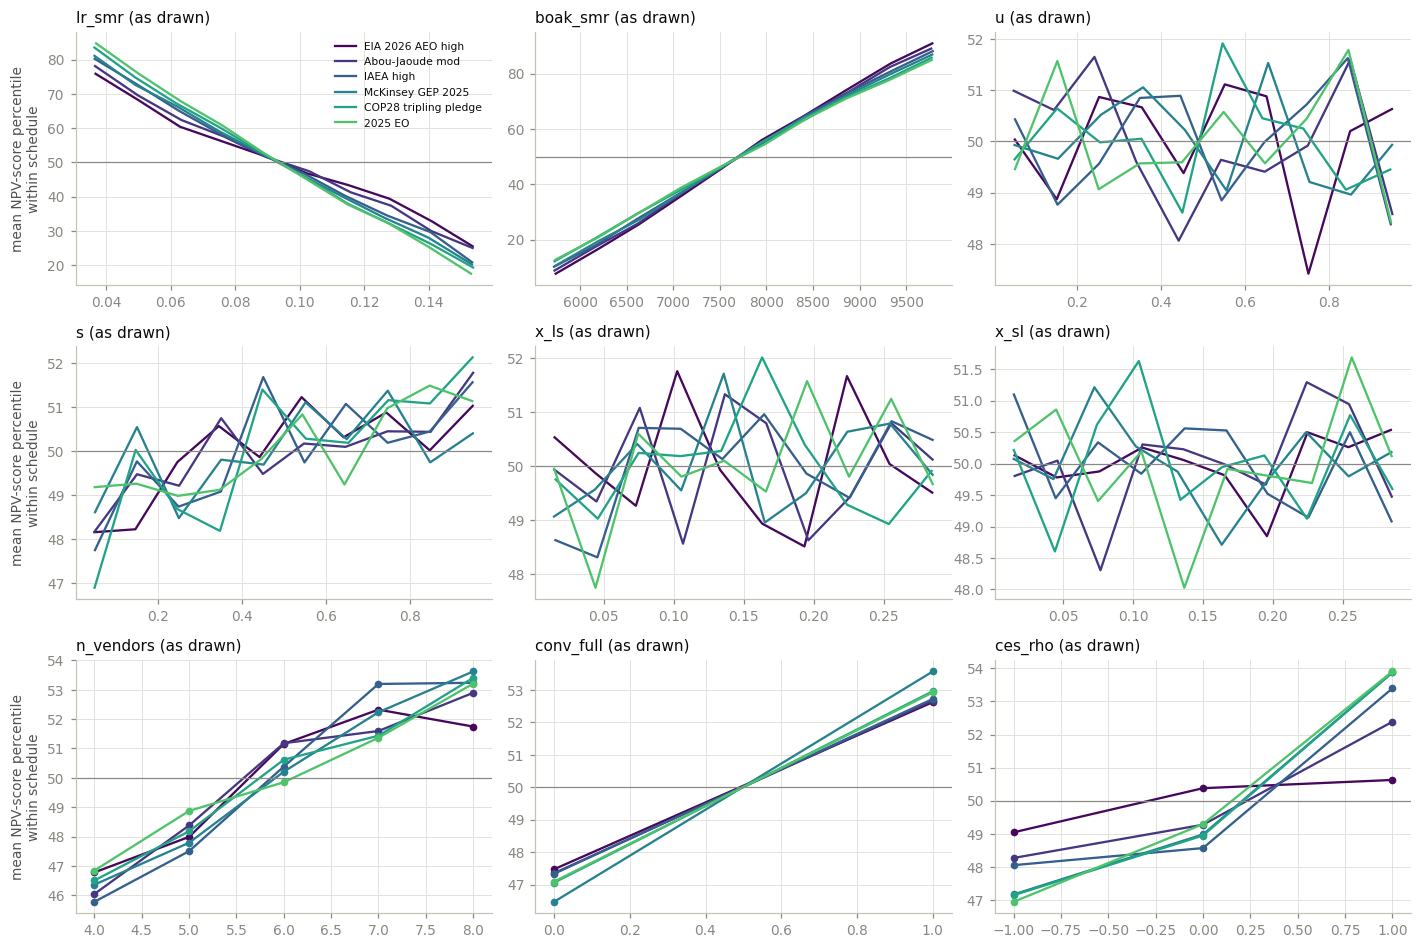

In [9]:
# --- Cross-check in the Monte Carlo itself: mean score percentile vs each drawn parameter ---
# The OAT sweep is the effect at the central world; this is the AVERAGE effect over the whole
# joint distribution (all interactions and the lr<->boak copula correlation included). The
# corner design is safe where the two agree on direction and rough shape.
MC_COL = {"U_lr": "lr_smr", "U_boak": "boak_smr"}
print("Monte Carlo cross-check — mean score percentile by parameter decile "
      "(average effect, interactions included)")
fig, axes = plt.subplots(3, 3, figsize=(ps.W3, 8.7))
for ax, p in zip(axes.ravel(), SWEEP_GRID):
    col = MC_COL.get(p, p)
    for s in SCHED_ORDER:
        x = WORLDS[s][col].to_numpy(float)
        pctile = 100.0*stats.rankdata(mc_score[s])/len(mc_score[s])
        if p in DISCRETE:
            vals = np.unique(x)
            ax.plot(vals, [pctile[x == v].mean() for v in vals],
                    color=SCHED_COLORS[s], lw=1.5, marker="o", ms=4, label=s)
        else:
            edges = np.quantile(x, np.linspace(0.0, 1.0, 11))
            idx = np.clip(np.searchsorted(edges, x, side="right") - 1, 0, 9)
            mids = 0.5*(edges[1:] + edges[:-1])
            ax.plot(mids, [pctile[idx == b].mean() for b in range(10)],
                    color=SCHED_COLORS[s], lw=1.5, label=s)
    ax.axhline(50.0, color=ps.FAINT, lw=0.8)
    ax.set_title(f"{col} (as drawn)")
axes[0, 0].legend(fontsize=7)
for ax in axes[:, 0]:
    ax.set_ylabel("mean NPV-score percentile\nwithin schedule")
fig.tight_layout()
ps.savefig(fig, FIGURES / "smr100_mc_trend_check.png")
plt.show()

## Possibility-frontier bounds (appendix + pilot instruments)

The lo/hi worlds are **not production cases** (v10, 2026-08-06): they are kept as (i) the
appendix **possibility frontier** — how cheap/expensive the program NPV could possibly get
over the priors' full support — and (ii) the **dual-monotonicity pilot instruments** (one
schedule's pair is exported below as `blo`/`bhi`: their input paths pointwise-dominate every
draw, so their ReEDS dual trajectories must not cross; QA-4e certifies the dominance).

- **lo / hi** — the cost-minimizing / cost-maximizing world over *all* variables. The two
  dials and `dur_z` are pinned at their certified-monotone extreme for each direction; the
  six interacting variables — `u`, `s`, `dur_lambda` × `ces_rho`, `conv_full`, `n_vendors`
  — are **jointly enumerated on a full grid** (21³ × 4 × 2 × 5 = 370,440 worlds per schedule
  per direction), so their interactions are handled exactly rather than by direction
  reasoning. A coordinate re-verification then sweeps *every* variable across its full range
  at each found optimum and confirms nothing can improve the bound — the pinned variables'
  certificate on top of the enumerated ones' exhaustiveness.

**The `dur_z` cap** (appendix caveat, moves with the bounds). `dur_z` is an unbounded
standard-normal draw (× the σ̂ = 0.116 residual sd of the 21-unit PRIS duration panel), so
the bounding worlds must truncate it somewhere: the cap is **±2.33 — the 1st/99th percentile
of the fitted project-noise distribution**, i.e. duration multipliers of ×0.76 / ×1.31. This
is a chosen coverage quantile (kept 2026-08-03), pending an explicit justification in the
paper; the bounds are bounds *conditional on it*.

The lo/hi worlds are **bounding scenarios**, not percentiles — the table prints where each
lands in the schedule's own 10k-draw NPV distribution (P0/P100 by construction). They are a
possibility statement: corner worlds carry no probability mass, which is exactly why they
were demoted from production cases to this appendix role.

For the figures below, the **literature-expected overlay world** (zero-run — an annotation,
never a case) is:

| input | value | source |
|---|---|---|
| LR large / SMR | 8% / 9.5% | Abou-Jaoude et al. (2024) firm-level rates (companion S4 card) |
| BOAK large / SMR | ATB 2024 moderate 2030 capcost | the central member of the same advanced↔conservative axis whose ends define the drawn ranges (Abou-Jaoude Table A-1 / ATB) |
| FOM, VOM | ATB 2024 moderate 2030 rows | same file — overlay only; the production cases use the U1-comonotone mapping |
| `conv_full` | 0 (tiny-base) | *is* the Abou-Jaoude anchor convention (companion D8) |
| `ces_rho` | 0 (multiplicative) | *is* the status-quo D9 form, i.e. Abou-Jaoude eq. 12's structure |
| `n_vendors` | 4 | Abou-Jaoude et al. (2024) market structure (m = 4; adopted 2026-08-03) |
| `dur_lambda` | 0.5 | midpoint of the two INL literature curves (λ=0 optimistic, λ=1 moderate; INL/RPT-25-84701 gives both and no stated central) |
| `u`, `s` | 0.5 | scenario envelopes with no published central; range center |
| `dur_z` | 0 | median project-noise draw |

In [10]:
# --- Possibility-frontier bounds (appendix + pilot instruments): exact lo/hi min/max
# of the program NPV, joint enumeration of the interacting six ---
import time as _time
_t0 = _time.time()
DZ_CAP = 2.33                                    # ~P1/P99 of the duration noise draw
_G21 = np.linspace(0.0, 1.0, 21)
_mesh = np.meshgrid(U_GRID, _G21, _G21, indexing="ij")
CONT = {"u": _mesh[0].ravel(), "s": _mesh[1].ravel(), "dur_lambda": _mesh[2].ravel()}
NPTS = len(CONT["u"])
DISC_COMBOS = [(rho, conv, m) for rho in CES_RHO_GRID for conv in (0.0, 1.0)
               for m in (4.0, 5.0, 6.0, 7.0, 8.0)]

def pinned(direction):
    """Dial/dur_z settings for the cheap (-1) or expensive (+1) bounding world."""
    return {"U_lr": 0.0 if direction > 0 else 1.0,      # slow learning is expensive
            "U_boak": 1.0 if direction > 0 else 0.0,    # high anchor is expensive
            "x_ls": 0.15,                               # inert for the SMR NPV (no large program)
            "x_sl": 0.15,                               # inert for the SMR NPV (loser export only)
            "dur_z": DZ_CAP*direction}                  # long builds are expensive

BOUNDS = {}      # BOUNDS[(sched, 'lo'|'hi')] -> {'world': dial-space dict, 'score': float}
for direction, tag in ((-1, "lo"), (+1, "hi")):
    best = {s: None for s in SCHED_ORDER}
    for rho, conv, m in DISC_COMBOS:
        settings = dict(CONT)
        settings.update({"ces_rho": np.full(NPTS, rho), "conv_full": np.full(NPTS, conv),
                         "n_vendors": np.full(NPTS, m)})
        settings.update({k: np.full(NPTS, v) for k, v in pinned(direction).items()})
        w = make_world(settings, NPTS)
        for sched in SCHED_ORDER:
            sc = program_npv(w, sched)
            i = int(np.argmin(sc) if direction < 0 else np.argmax(sc))
            if best[sched] is None or direction*(sc[i] - best[sched]["score"]) > 0:
                best[sched] = {"score": float(sc[i]),
                               "world": {k: float(np.asarray(v)[i]) for k, v in settings.items()}}
    for sched in SCHED_ORDER:
        BOUNDS[(sched, tag)] = best[sched]
print(f"enumerated {2*len(DISC_COMBOS)*NPTS:,} worlds x {len(SCHED_ORDER)} schedules "
      f"in {_time.time()-_t0:.0f}s")

# Coordinate re-verification: sweep EVERY variable across its full range with the others
# held at the found optimum; no sweep may improve the bound.
VERIFY_GRID = {"U_lr": _G21, "U_boak": _G21, "u": U_GRID.copy(), "s": _G21,
               "x_ls": np.linspace(0.0, X_SPILL_MAX, 21),
               "x_sl": np.linspace(0.0, X_SPILL_MAX, 21),
               "n_vendors": np.arange(4, 9, dtype=float), "conv_full": np.array([0.0, 1.0]),
               "ces_rho": CES_RHO_GRID.copy(), "dur_lambda": _G21,
               "dur_z": np.linspace(-DZ_CAP, DZ_CAP, 21)}
_n_fail = 0
for (sched, tag), b in BOUNDS.items():
    direction = -1 if tag == "lo" else +1
    for p, grid in VERIFY_GRID.items():
        st = {k: np.full(len(grid), v) for k, v in b["world"].items()}
        st[p] = grid
        sc = program_npv(make_world(st, len(grid)), sched)
        ext = float(sc.min() if direction < 0 else sc.max())
        if direction*(ext - b["score"]) > 1e-7*abs(b["score"]):
            _n_fail += 1
            print(f"  FAIL {sched} {tag}: sweeping {p} improves the bound by "
                  f"{abs(ext - b['score'])/abs(b['score']):.3%}")
if _n_fail == 0:
    print("bounds verification PASSED: at every schedule's lo/hi world, no variable can be "
          "moved anywhere in its range to improve the bound")
else:
    print(f"bounds verification finished with {_n_fail} FAILURES (see above)")

_rows = []
for (sched, tag), b in BOUNDS.items():
    w = b["world"]
    _rows.append({"schedule": sched, "case": tag, "score": round(b["score"], 0),
                  "pctile_in_MC": round(100*float((mc_score[sched] < b["score"]).mean()), 2),
                  **{k: round(v, 3) for k, v in w.items()}})
bounds_df = pd.DataFrame(_rows).set_index(["schedule", "case"]).sort_index()
print("\nPossibility-frontier bounds (appendix + pilot instruments; dial units) and "
      "where each lands in its own MC:")
print(bounds_df.to_string())
bounds_df.to_csv(EXPORTS / "bounds_record.csv")
print("\nbounds record frozen to exports/smr100/bounds_record.csv "
      "(the old designed_cases.csv name retires)")

enumerated 555,660 worlds x 6 schedules in 55s


bounds verification PASSED: at every schedule's lo/hi world, no variable can be moved anywhere in its range to improve the bound

Possibility-frontier bounds (appendix + pilot instruments; dial units) and where each lands in its own MC:
                                score  pctile_in_MC    u    s  dur_lambda  ces_rho  conv_full  n_vendors  U_lr  U_boak  x_ls  x_sl  dur_z
schedule              case                                                                                                               
2025 EO               hi    2784514.0         100.0  0.0  1.0         0.3      1.0        1.0        8.0   0.0     1.0  0.15  0.15   2.33
                      lo     823011.0           0.0  1.0  1.0         0.0      1.0        0.0        4.0   1.0     0.0  0.15  0.15  -2.33
Abou-Jaoude mod       hi     306877.0         100.0  0.0  1.0         0.3      1.0        1.0        8.0   0.0     1.0  0.15  0.15   2.33
                      lo     107054.0           0.0  1.0  1.0         0.0

## Production cases: the P5/P50/P95 joint draws

The exported cases return to **actual joint draws** (v10): for each schedule, the drawn
worlds whose program NPV sits at the P5/P50/P95 ranks of the schedule's own 10,000-draw
distribution. Every case is a plausible world with probability mass under the elicited
priors — the constrained optimizer's answer at the 90% plausibility level — and its draw
index, score, and full parameter row are registered to `exports/smr100/selected_draws.csv`
(with a draw-identity assert against the companion's `mc_perdraw.npz`, extending QA-0's
sample-space guarantee to the cases themselves). The coverage cell then reports the
band's coverage as a **layered claim** (ratified 2026-08-06): (i) **90% by construction**
on program cost — the scalar the cases are drawn at; (ii) the **empirical simultaneous
bracket coverage** (~0.62–0.81) for the year-by-year subsidy bracket; and (iii) the
**one-sided coverage** — the chance a drawn path never exceeds the p95 case's path — which
is higher and is the direction policy cares about (the fiscal risk is a bracket overrun,
not an underrun). The bounds pair below still anchors the extremes with certainty.

In [11]:
# --- Production-case selection (v10, 2026-08-06): the P5/P50/P95 joint draws per schedule ---
# Rank the 10k drawn worlds by the program NPV (mc_score) and take the draws at the
# P5/P50/P95 ranks (rank = ceil(q*(N-1)) of the stable argsort). The cases are actual joint
# draws -- plausible worlds with probability mass -- selected as a constrained optimizer over
# the drawn (plausible) set; the lo/hi bounds above remain the appendix possibility frontier
# over the priors' full support.
PCT_TAGS = {"p05": 0.05, "p50": 0.50, "p95": 0.95}
SELECTED = {}                # SELECTED[(sched, tag)] -> {"idx": draw index, "score": float}
_sel_rows = []
for sched in SCHED_ORDER:
    order = np.argsort(mc_score[sched], kind="stable")
    for tag, q in PCT_TAGS.items():
        idx = int(order[int(np.ceil(q * (N_DRAWS - 1)))])
        SELECTED[(sched, tag)] = {"idx": idx, "score": float(mc_score[sched][idx])}
        _sel_rows.append({"schedule": sched, "percentile": tag, "draw_index": idx,
                          "score": float(mc_score[sched][idx]),
                          "pctile_in_MC": round(100*float(
                              (mc_score[sched] < mc_score[sched][idx]).mean()), 3),
                          **{c: float(WORLDS[sched].iloc[idx][c])
                             for c in WORLDS[sched].columns}})
sel_df = pd.DataFrame(_sel_rows).set_index(["schedule", "percentile"])
sel_df.to_csv(EXPORTS / "selected_draws.csv")

# Draw-identity assert: each selected draw's parameter row must match the companion's
# per-draw export (extends QA-0's sample-space identity to the cases themselves).
_npz_sel_path = NB_DIR / "exports" / "mc_perdraw.npz"
_sel_checked = 0
if _npz_sel_path.exists():
    _npz_sel = np.load(_npz_sel_path, allow_pickle=False)
    _sel_cols = list(_npz_sel["world_columns"].astype(str))
    for (sched, tag), s in SELECTED.items():
        tok = SCEN_TOKEN[sched]
        if _npz_sel[f"worlds_{tok}"].shape[0] != N_DRAWS:
            print("selected-draw identity SKIPPED: mc_perdraw.npz draw count differs "
                  "from this run -- re-run the companion notebook to compare")
            break
        assert _sel_cols == list(WORLDS[sched].columns), "world column layout diverged"
        assert np.allclose(_npz_sel[f"worlds_{tok}"][s["idx"]],
                           WORLDS[sched].iloc[s["idx"]].to_numpy(dtype=float),
                           rtol=1e-9, atol=0), (sched, tag)
        _sel_checked += 1
    if _sel_checked:
        print(f"selected-draw identity vs mc_perdraw.npz: all {_sel_checked} case rows match "
              "their registered draw (rtol 1e-9)")
else:
    print("mc_perdraw.npz not found -- selected-draw identity check skipped "
          "(run the companion notebook to enable it)")

print("\nSelected production draws (registered to exports/smr100/selected_draws.csv):")
print(sel_df[["draw_index", "score", "pctile_in_MC"]].to_string())

selected-draw identity vs mc_perdraw.npz: all 18 case rows match their registered draw (rtol 1e-9)

Selected production draws (registered to exports/smr100/selected_draws.csv):
                                  draw_index         score  pctile_in_MC
schedule              percentile                                        
EIA 2026 AEO high     p05               2329  1.074627e+05           5.0
                      p50               9573  1.481451e+05          50.0
                      p95               6874  1.950652e+05          95.0
Abou-Jaoude mod       p05               6077  1.399636e+05           5.0
                      p50                242  1.971983e+05          50.0
                      p95                162  2.659700e+05          95.0
IAEA high             p05               8423  3.268254e+05           5.0
                      p50               4993  4.708006e+05          50.0
                      p95               7602  6.512874e+05          95.0
McKinsey GEP 2025   

In [12]:
# --- Coverage of the selected p05-p95 band: the layered claim (ratified 2026-08-06) ---
# Cases unchanged by the coverage finding; the claim is layered:
#   (i)  90% BY CONSTRUCTION on program cost (the scalar NPV ranking the cases are drawn at);
#   (ii) the empirical SIMULTANEOUS bracket coverage: the fraction of all 10k paths lying
#        entirely inside the [p05-draw path, p95-draw path] band year-by-year (~0.62-0.81);
#   (iii) the ONE-SIDED coverage -- the chance a drawn path never exceeds the p95 case's
#        path in any year (cov_below_p95) -- higher than (ii), and the direction policy
#        cares about: the fiscal risk is a bracket overrun, not an underrun. The mirror
#        (cov_above_p05) is reported for symmetry.
# All over the exported horizon (>= ANCHOR; pre-anchor years keep ATB values). Optional
# extra: the pointwise-quantile level q* whose [Pq*, P(100-q*)] band calibrates to 90%
# empirical simultaneous coverage (figure/number only -- never cases).
_cov_years = YEARS >= ANCHOR

def _sim_cov(paths, band_lo, band_hi):
    p = paths[:, _cov_years]
    return float(((p >= band_lo[None, _cov_years] - 1e-9) &
                  (p <= band_hi[None, _cov_years] + 1e-9)).all(axis=1).mean())

_cov_rows = []
for sched in SCHED_ORDER:
    row = {"schedule": sched, "scalar_by_construction": 0.90}
    for ch, lab in (("fincapex_smr", "fincapex"), ("occ_smr", "occ")):
        paths = results[sched][ch]
        p = paths[:, _cov_years]
        lo_p = paths[SELECTED[(sched, "p05")]["idx"]][_cov_years]
        hi_p = paths[SELECTED[(sched, "p95")]["idx"]][_cov_years]
        row[f"simult_cov_{lab}"] = round(float(
            ((p >= np.minimum(lo_p, hi_p)[None, :] - 1e-9) &
             (p <= np.maximum(lo_p, hi_p)[None, :] + 1e-9)).all(axis=1).mean()), 4)
        row[f"cov_below_p95_{lab}"] = round(float(
            (p <= hi_p[None, :] + 1e-9).all(axis=1).mean()), 4)
        row[f"cov_above_p05_{lab}"] = round(float(
            (p >= lo_p[None, :] - 1e-9).all(axis=1).mean()), 4)
    # calibrated pointwise pair (fincapex): bisect the quantile level to 90% simultaneous
    paths = results[sched]["fincapex_smr"]
    qlo, qhi = 0.01, 5.0          # wide (high coverage) .. narrow (low coverage)
    for _ in range(40):
        qm = 0.5*(qlo + qhi)
        c = _sim_cov(paths, np.percentile(paths, qm, axis=0),
                     np.percentile(paths, 100.0 - qm, axis=0))
        if c > 0.90:
            qlo = qm
        else:
            qhi = qm
    row["calibrated_pointwise_q"] = round(0.5*(qlo + qhi), 3)
    _cov_rows.append(row)
band_cov = pd.DataFrame(_cov_rows).set_index("schedule")
band_cov.to_csv(EXPORTS / "band_coverage.csv")
print("Layered coverage of the selected p05-p95 pair (years >= 2030): 90% by construction "
      "on program cost;\nsimult_cov_* = two-sided year-by-year bracket; cov_below_p95_* = "
      "one-sided (path never exceeds the p95 case's -- the policy direction);\n"
      "q* = pointwise level whose band reaches 90% simultaneous coverage (figure only):")
print(band_cov.to_string())

Layered coverage of the selected p05-p95 pair (years >= 2030): 90% by construction on program cost;
simult_cov_* = two-sided year-by-year bracket; cov_below_p95_* = one-sided (path never exceeds the p95 case's -- the policy direction);
q* = pointwise level whose band reaches 90% simultaneous coverage (figure only):
                       scalar_by_construction  simult_cov_fincapex  cov_below_p95_fincapex  cov_above_p05_fincapex  simult_cov_occ  cov_below_p95_occ  cov_above_p05_occ  calibrated_pointwise_q
schedule                                                                                                                                                                                        
EIA 2026 AEO high                         0.9               0.6185                  0.8877                  0.7308          0.6562             0.8606             0.7956                    2.43
Abou-Jaoude mod                           0.9               0.6357                  0.8768              

literature overlay world (zero-run): lr 8%/9.5% (AJ), BOAK {'large': 5750.0, 'smr': 8000.0} (ATB moderate), FOM/VOM {'large': (175.0, 2.8), 'smr': (136.0, 2.6)}
annotation placements in each schedule's 10k-draw NPV distribution:
  EIA 2026 AEO high      blo P0.00   lit overlay P40.2   bhi P100.00
  Abou-Jaoude mod        blo P0.00   lit overlay P39.0   bhi P100.00
  IAEA high              blo P0.00   lit overlay P38.9   bhi P100.00
  McKinsey GEP 2025      blo P0.00   lit overlay P37.1   bhi P100.00
  COP28 tripling pledge  blo P0.00   lit overlay P38.2   bhi P100.00
  2025 EO                blo P0.00   lit overlay P37.9   bhi P100.00
Selected P5/P50/P95 joint draws over the Monte Carlo — possibility-frontier bounds (dashed) and literature overlay (dotted) as annotations


saved -> figures\smr100_selected_cases_fan.png


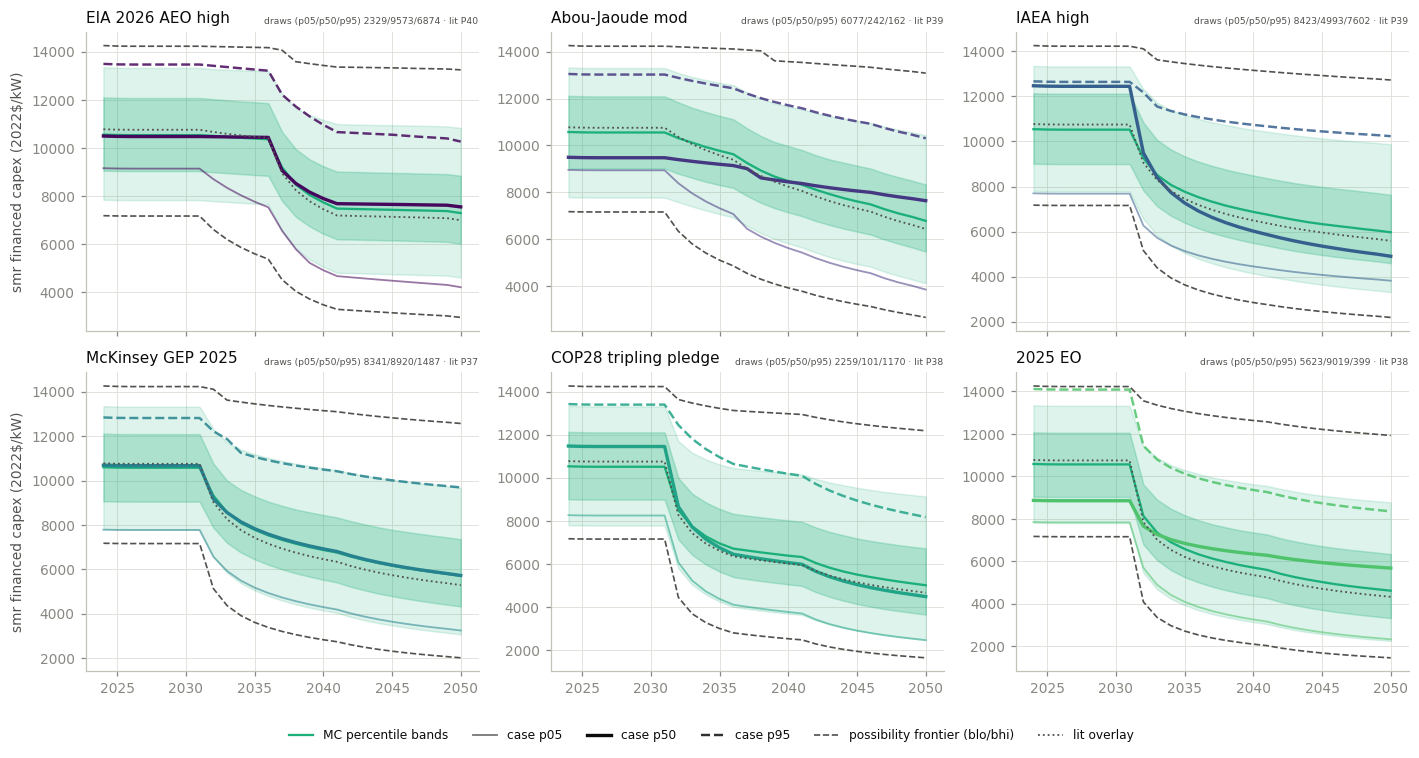

In [13]:
# --- Literature-expected overlay (zero-run) + the selected cases over the MC fans ---
LIT_LR = {"large": 0.08, "smr": 0.095}           # Abou-Jaoude firm-level rates (S4 card)
_mod30 = {t: pd.read_csv(PLANTCHAR_DIR / f"{_ATB_STEM[t]}_ATB_2024_moderate.csv")
              .set_index("t").loc[2030] for t in TECH}
for t in TECH:
    assert TECH[t]["boak_lo"] <= float(_mod30[t]["capcost"]) <= TECH[t]["boak_hi"], t
    assert TECH[t]["lr_lo"] <= LIT_LR[t] <= TECH[t]["lr_hi"], t
MID = {"u": 0.5, "s": 0.5, "x_ls": 0.15, "x_sl": 0.15, "n_vendors": 4.0, "conv_full": 0.0,
       "ces_rho": 0.0, "dur_lambda": 0.5, "dur_z": 0.0}   # conv/ces/m ARE literature (AJ m=4)

def lit_world(n=1):
    """The literature-expected overlay world in engine columns (lr/boak set per tech)."""
    w = pd.DataFrame(index=range(n))
    for t in TECH:
        w[f"lr_{t}"] = LIT_LR[t]
        w[f"boak_{t}"] = float(_mod30[t]["capcost"])
    for k, v in MID.items():
        w[k] = v
    return w

def smr_paths(world, sched):
    """(occ, dur, fincapex) rows for any world, exactly as the ranking computes them."""
    occ = occ_paths_ces(world, "smr", N_US_SMR[sched])
    dur = duration_paths(world, "smr", N_US_SMR[sched])
    return occ, dur, occ*ccmult_grid(dur, "smr")*FIN_REST["smr"][None, :]

def mid_score(sched):
    """Overlay-world program NPV with FOM/VOM at the ATB-moderate values (overlay only --
    the production cases use the U1-comonotone mapping)."""
    _, _, fc = smr_paths(lit_world(), sched)
    om = PVF_ONM*(float(_mod30["smr"]["fom"]) + MWH_PER_KWYR*float(_mod30["smr"]["vom"]))
    return float((fc[0] + om + _FUEL_PV["smr"]) @ (GW_ADD[sched]/DISC))

print("literature overlay world (zero-run): lr 8%/9.5% (AJ), BOAK",
      {t: float(_mod30[t]["capcost"]) for t in TECH}, "(ATB moderate), FOM/VOM",
      {t: (float(_mod30[t]["fom"]), float(_mod30[t]["vom"])) for t in TECH})
print("annotation placements in each schedule's 10k-draw NPV distribution:")
_pct = {}
for sched in SCHED_ORDER:
    r = mc_score[sched]
    _pct[sched] = {"blo": 100*float((r < BOUNDS[(sched, 'lo')]["score"]).mean()),
                   "lit": 100*float((r < mid_score(sched)).mean()),
                   "bhi": 100*float((r < BOUNDS[(sched, 'hi')]["score"]).mean())}
    print(f"  {sched:22s} blo P{_pct[sched]['blo']:.2f}   "
          f"lit overlay P{_pct[sched]['lit']:.1f}   bhi P{_pct[sched]['bhi']:.2f}")

# The v10 fan: MC bands, the three selected-draw case trajectories (solid), the lo/hi
# possibility-frontier bounds (dashed), and the literature overlay (dotted, zero-run).
print("Selected P5/P50/P95 joint draws over the Monte Carlo — possibility-frontier "
      "bounds (dashed) and literature overlay (dotted) as annotations")
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.5), sharex=True)
for ax, sched in zip(axes.ravel(), SCHED_ORDER):
    fc = results[sched]["fincapex_smr"]
    pct = percentile_table(fc)
    ax.fill_between(YEARS, pct["P5"], pct["P95"], alpha=0.15, color=ps.ACCENT["green"])
    ax.fill_between(YEARS, pct["P25"], pct["P75"], alpha=0.25, color=ps.ACCENT["green"])
    ax.plot(YEARS, pct["P50"], color=ps.ACCENT["green"], lw=1.5)
    _idx = {tag: SELECTED[(sched, tag)]["idx"] for tag in ("p05", "p50", "p95")}
    for tag in ("p05", "p50", "p95"):
        ax.plot(YEARS, fc[_idx[tag]], color=SCHED_COLORS[sched], **ps.PCT_STYLE[tag])
    for tag, btag in (("lo", "blo"), ("hi", "bhi")):
        w1 = make_world({k: [v] for k, v in BOUNDS[(sched, tag)]["world"].items()}, 1)
        ax.plot(YEARS, smr_paths(w1, sched)[2][0], color=ps.MUTED, ls="--", lw=1.1)
    ax.plot(YEARS, smr_paths(lit_world(), sched)[2][0], color=ps.MUTED, ls=":", lw=1.2)
    ax.set_title(sched)
    # panel-specific facts sit above the axes, clear of the data: the selected draw
    # ids and the lit overlay's percentile in THIS schedule's MC
    ax.text(1.0, 1.02, f"draws (p05/p50/p95) {_idx['p05']}/{_idx['p50']}/{_idx['p95']}"
            f" · lit P{_pct[sched]['lit']:.0f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=6, color=ps.MUTED)
for ax in axes[:, 0]:
    ax.set_ylabel("smr financed capex (2022$/kW)")
# one shared legend below the grid (every panel plots the same series); the case-line
# proxies are ink-neutral -- inside the panels they carry the schedule hue
from matplotlib.lines import Line2D
_handles = [Line2D([], [], color=ps.ACCENT["green"], lw=1.5, label="MC percentile bands")]
_handles += [Line2D([], [], color=ps.INK, **ps.PCT_STYLE[tag], label=f"case {tag}")
             for tag in ("p05", "p50", "p95")]
_handles += [Line2D([], [], color=ps.MUTED, ls="--", lw=1.1,
                    label="possibility frontier (blo/bhi)"),
             Line2D([], [], color=ps.MUTED, ls=":", lw=1.2, label="lit overlay")]
fig.tight_layout()
fig.legend(handles=_handles, loc="upper center", bbox_to_anchor=(0.5, -0.01),
           ncol=6, fontsize=8)
ps.savefig(fig, FIGURES / "smr100_selected_cases_fan.png")
plt.show()

### Reading the cases, bounds, and overlay

Three views, all on the program-NPV scale:

1. **Placement** — each schedule's full 10k-draw NPV distribution with the **selected
   P5/P50/P95 draws marked as the cases** (colored solid lines at their scores). The lo/hi
   possibility-frontier bounds (grey dashed, strictly outside the drawn support) and the
   literature-expected overlay (grey dotted, ~P38–40) are annotations, not cases.
2. **Attribution** (appendix) — what each variable contributes to the lo/hi bounds, measured
   both ways: *move one variable alone* from the central world to its bound setting (its
   solo effect), and *restore one variable to central* from the full bound world (its
   marginal contribution in place, interactions included). The gap between the summed solo
   effects and the joint total is the **interaction residual** — the part per-variable
   reasoning cannot see. Bars are means across the six schedules; whiskers span min–max.
3. **The flagship interaction** (appendix) — program cost vs spillover `s` under both
   experience-base conventions: under tiny-base spillover only adds post-anchor foreign
   experience (cheapens), while under full-stock it also couples the static θ-weighted
   historical world fleet into the 2030 anchor base, diluting the program's relative
   learning (raises cost). That slope flip is why `s = 1` appears in *both* the lo and the
   hi worlds, and why the same is true of `ces_rho = 1` (substitutable channels amplify
   whichever way the cross-firm channel is pointing).

> **Tie-set caveat.** The recorded lo/hi dial values are one member of a *tie set*: on the
> piecewise-constant axes (`dur_lambda` through the ccmult year-rounding, and any dial on a
> flat stretch of the objective) several settings attain the identical bound, and the argmin
> records whichever the enumeration visited first (e.g. `dur_lambda` 0.0/0.3 in hi worlds
> where 1.0 ties). The coordinate re-verification passes on ties by construction. Read the
> attribution bars as members of the optimal set, not unique attributions.

Where the cases sit — selected P5/P50/P95 joint draws (solid); possibility-frontier bounds and literature overlay as annotations


saved -> figures\smr100_case_placement.png


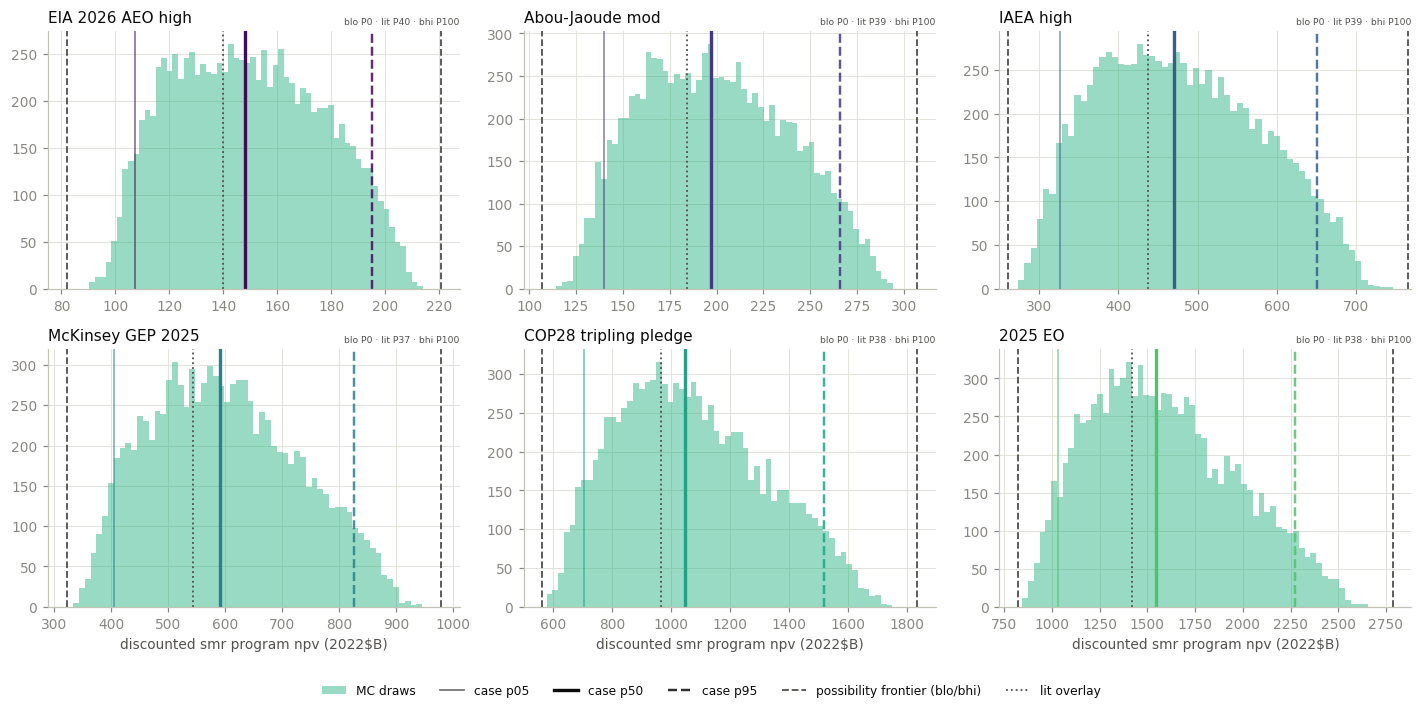

Why the bounds are where they are — per-variable contributions (mean across schedules, whiskers min-max)


saved -> figures\smr100_bound_attribution.png


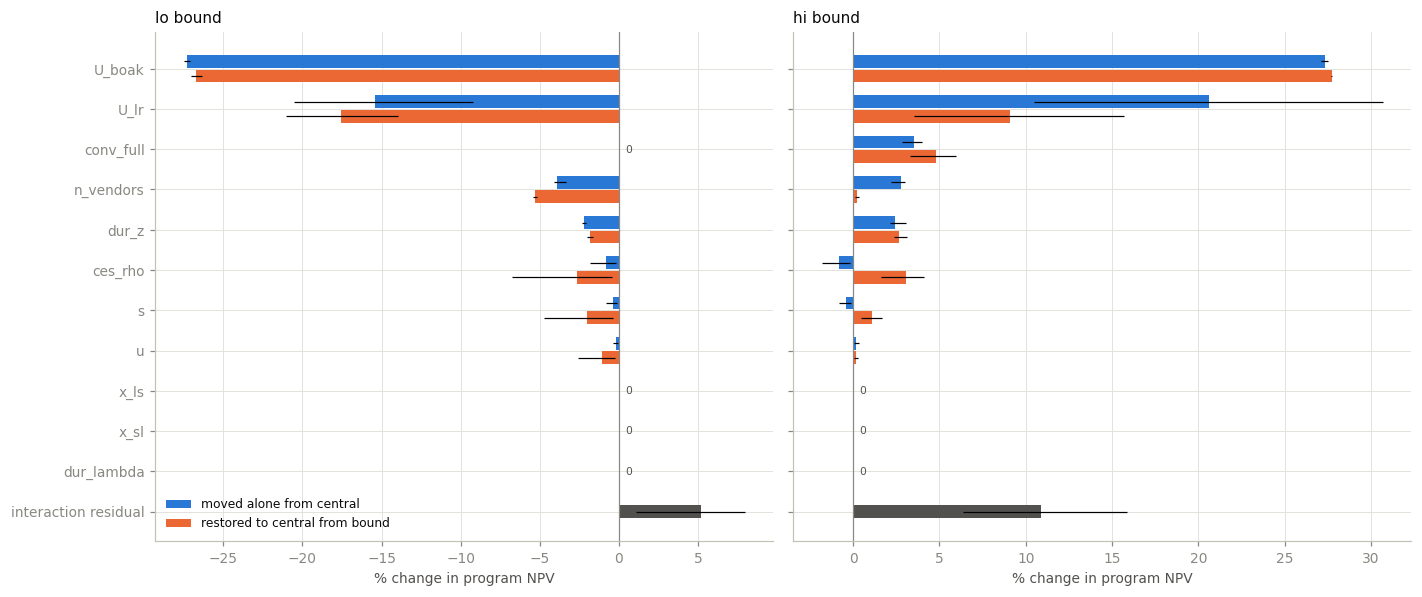

The s × experience-base interaction: spillover cheapens under tiny-base but couples the static world fleet into the anchor base under full-stock


saved -> figures\smr100_s_conv_interaction.png


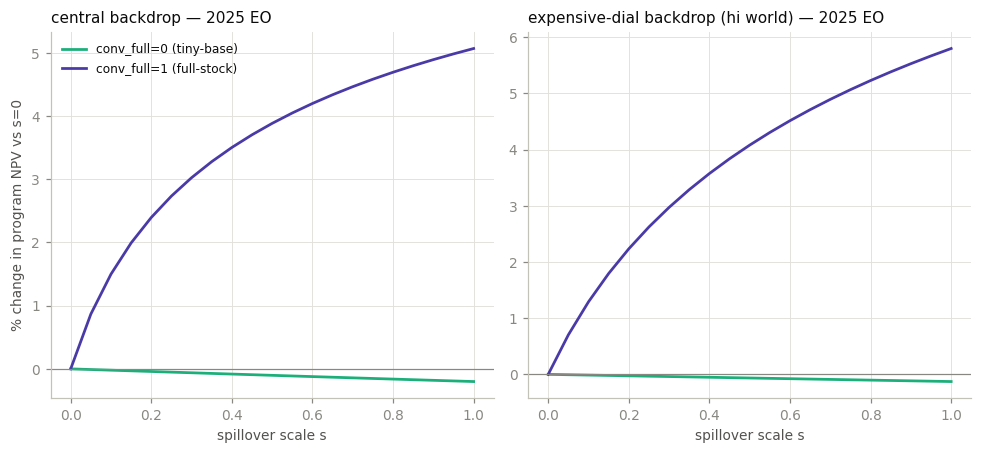

In [14]:
# Visual analysis 1 — placement: selected cases (solid) vs the full drawn NPV distribution;
# possibility-frontier bounds and literature overlay as annotations
print("Where the cases sit — selected P5/P50/P95 joint draws (solid); "
      "possibility-frontier bounds and literature overlay as annotations")
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.1))
for ax, sched in zip(axes.ravel(), SCHED_ORDER):
    r = mc_score[sched] / 1e3                      # discounted program NPV, $bn
    ax.hist(r, bins=60, color=ps.ACCENT["green"], alpha=0.45)
    for tag in ("p05", "p50", "p95"):
        ax.axvline(SELECTED[(sched, tag)]["score"]/1e3, color=SCHED_COLORS[sched],
                   **ps.PCT_STYLE[tag])
    for tag in ("lo", "hi"):
        ax.axvline(BOUNDS[(sched, tag)]["score"]/1e3, color=ps.MUTED, ls="--", lw=1.2)
    ax.axvline(mid_score(sched)/1e3, color=ps.MUTED, ls=":", lw=1.2)
    ax.set_title(sched)
    # the annotation lines' percentiles in THIS schedule's MC, above the axes and
    # clear of the data
    ax.text(1.0, 1.02, f"blo P{_pct[sched]['blo']:.0f} · lit P{_pct[sched]['lit']:.0f}"
            f" · bhi P{_pct[sched]['bhi']:.0f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=6, color=ps.MUTED)
for ax in axes[1, :]:
    ax.set_xlabel("discounted smr program npv (2022$B)")
# one shared legend below the grid; case-line proxies ink-neutral (schedule hue in-panel)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
_handles = [Patch(facecolor=ps.ACCENT["green"], alpha=0.45, label="MC draws")]
_handles += [Line2D([], [], color=ps.INK, **ps.PCT_STYLE[tag], label=f"case {tag}")
             for tag in ("p05", "p50", "p95")]
_handles += [Line2D([], [], color=ps.MUTED, ls="--", lw=1.2,
                    label="possibility frontier (blo/bhi)"),
             Line2D([], [], color=ps.MUTED, ls=":", lw=1.2, label="lit overlay")]
fig.tight_layout()
fig.legend(handles=_handles, loc="upper center", bbox_to_anchor=(0.5, -0.01),
           ncol=6, fontsize=8)
ps.savefig(fig, FIGURES / "smr100_case_placement.png")
plt.show()

# Visual analysis 2 — attribution: what pushes each bound away from the central world
def score_of(settings, sched):
    return float(program_npv(make_world({k: [v] for k, v in settings.items()}, 1), sched)[0])

ATTR = {}
for tag in ("lo", "hi"):
    rows = {p: {"solo": [], "in_place": []} for p in SWEEP_GRID}
    inter = []
    for sched in SCHED_ORDER:
        bw = BOUNDS[(sched, tag)]["world"]
        s_base, s_bound = base_score[sched], BOUNDS[(sched, tag)]["score"]
        solo_sum = 0.0
        for p in SWEEP_GRID:
            st = dict(BASE_WORLD); st[p] = bw[p]
            d_solo = score_of(st, sched)/s_base - 1.0
            rows[p]["solo"].append(100*d_solo)
            solo_sum += d_solo
            st2 = dict(bw); st2[p] = BASE_WORLD[p]
            rows[p]["in_place"].append(100*(s_bound/score_of(st2, sched) - 1.0))
        inter.append(100*((s_bound/s_base - 1.0) - solo_sum))
    ATTR[tag] = (rows, inter)

_order = sorted(SWEEP_GRID, key=lambda p: -abs(np.mean(ATTR["hi"][0][p]["solo"])))
_ylab = _order + ["interaction residual"]
_ypos = np.arange(len(_ylab))[::-1]
print("Why the bounds are where they are — per-variable contributions "
      "(mean across schedules, whiskers min-max)")
fig, axes = plt.subplots(1, 2, figsize=(ps.W3, 5.5), sharey=True)
for ax, tag in zip(axes, ("lo", "hi")):
    rows, inter = ATTR[tag]
    for kind, off, color, lab in (("solo", 0.18, ps.ACCENT["blue"], "moved alone from central"),
                                  ("in_place", -0.18, ps.ACCENT["orange"],
                                   "restored to central from bound")):
        m = np.array([np.mean(rows[p][kind]) for p in _order])
        lo_ = np.array([np.min(rows[p][kind]) for p in _order])
        hi_ = np.array([np.max(rows[p][kind]) for p in _order])
        ax.barh(_ypos[:len(_order)] + off, m, height=0.32, color=color,
                xerr=[m - lo_, hi_ - m], error_kw={"lw": 0.8}, label=lab)
    # exact-zero rows (the inert dials) get an explicit 0 marker so the empty
    # rows read as "no contribution", not missing data
    for p, y0 in zip(_order, _ypos[:len(_order)]):
        if max(abs(v) for v in rows[p]["solo"] + rows[p]["in_place"]) < 1e-9:
            ax.annotate("0", (0.0, float(y0)), xytext=(4, 0),
                        textcoords="offset points", ha="left", va="center",
                        fontsize=7, color=ps.MUTED)
    ax.barh(_ypos[-1], np.mean(inter), height=0.32, color=ps.MUTED,
            xerr=[[np.mean(inter) - min(inter)], [max(inter) - np.mean(inter)]],
            error_kw={"lw": 0.8})
    ax.axvline(0.0, color=ps.FAINT, lw=0.8)
    ax.set_yticks(_ypos, labels=_ylab)
    ax.set_title(f"{tag} bound")
    ax.set_xlabel("% change in program NPV")
axes[0].legend(fontsize=8)
fig.tight_layout()
ps.savefig(fig, FIGURES / "smr100_bound_attribution.png")
plt.show()

# Visual analysis 3 — the s x conv_full slope flip that puts s=1 in BOTH bounds
_sched3 = SCHED_ORDER[-1]                # 2025 EO; the directions are common to all schedules
_sgrid = np.linspace(0.0, 1.0, 21)
print("The s × experience-base interaction: spillover cheapens under tiny-base but "
      "couples the static world fleet into the anchor base under full-stock")
fig, axes = plt.subplots(1, 2, figsize=(ps.W2, 4.2))
for ax, (title, back) in zip(axes, (("central backdrop", dict(BASE_WORLD)),
                                    ("expensive-dial backdrop (hi world)",
                                     dict(BOUNDS[(_sched3, "hi")]["world"])))):
    for conv, color in ((0.0, ps.C_TINY), (1.0, ps.C_FULL)):   # experience-base strata
        st = {k: np.full(len(_sgrid), v) for k, v in back.items()}
        st["conv_full"] = np.full(len(_sgrid), conv)
        st["s"] = _sgrid
        sc = program_npv(make_world(st, len(_sgrid)), _sched3)
        ax.plot(_sgrid, 100.0*(sc/sc[0] - 1.0), color=color, lw=1.8,
                label=f"conv_full={int(conv)} ({'full-stock' if conv else 'tiny-base'})")
    ax.axhline(0.0, color=ps.FAINT, lw=0.8)
    ax.set_title(f"{title} — {_sched3}")
    ax.set_xlabel("spillover scale s")
axes[0].set_ylabel("% change in program NPV vs s=0")
axes[0].legend(fontsize=8)
fig.tight_layout()
ps.savefig(fig, FIGURES / "smr100_s_conv_interaction.png")
plt.show()

In [15]:
# --- The 18 exported cases, built from the selected P5/P50/P95 joint draws ---
N_US_PROG = {"smr": N_US_SMR, "large": N_US_LARGE}   # program-tech unit counts per schedule

def build_case_rec(case, sched, tag, w1, score, extra, program="smr", score_dist=None):
    """One export-ready case record: parameters, U1-comonotone O&M, and the (T,) occ/dur
    path arrays -- shared by the production cases, the pilot bounds pair (no ATB-moderate
    special case anymore, v10), and the large100 comparators. `program` is the tech that
    receives the entire build program (the 'winner' field records it; the other tech rides
    the loser channel); `score_dist` is the ranking the case's percentile is measured in
    (defaults to the SMR program ranking mc_score)."""
    fomvom = {t: tuple(float(x) for x in om_at(t, float(u1_of(w1)[0]))) for t in TECH}
    r = w1.iloc[0]
    dist = mc_score[sched] if score_dist is None else score_dist
    rec = {"case": case, "schedule": sched, "scen_token": SCEN_TOKEN[sched], "case_type": tag,
           "winner": program,          # the tech assumed to receive the entire program
           "lr_large": float(r["lr_large"]), "lr_smr": float(r["lr_smr"]),
           "boak_large": float(r["boak_large"]), "boak_smr": float(r["boak_smr"]),
           "u": float(r["u"]), "s_spill": float(r["s"]),
           "x_ls": float(r["x_ls"]), "x_sl": float(r["x_sl"]),
           "n_vendors": int(r["n_vendors"]),
           "convention": "full-stock" if r["conv_full"] else "tiny-base",
           "ces_rho": float(r["ces_rho"]), "dur_lambda": float(r["dur_lambda"]),
           "dur_z": float(r["dur_z"]),
           "score": float(score),
           "pctile_in_MC": round(100*float((dist < score).mean()), 2),
           **extra,
           **{f"{k}_{t}": v for t in TECH for k, v in zip(("fom", "vom"), fomvom[t])}}
    other = "large" if program == "smr" else "smr"
    for tech, n_us, n_oth in ((program, N_US_PROG[program][sched], None),
                              (other, ZEROS_T, N_US_PROG[program][sched])):
        occ = occ_paths_ces(w1, tech, n_us, n_oth=n_oth)[0]
        dur = duration_paths(w1, tech, n_us)[0]
        rec[f"occ_{tech}"], rec[f"dur_{tech}"] = occ, dur    # (T,) arrays for the exports
        for y in (2030, 2040, 2050):
            rec[f"occ_{tech}_{y}"] = round(float(occ[yi(y)]), 0)
            rec[f"dur_{tech}_{y}"] = round(float(dur[yi(y)]), 0)
    return rec

CASES = {}           # CASES[case_name] -> the selected joint draw's record (+ (T,) arrays)
for sched in SCHED_ORDER:
    tok = SCEN_TOKEN[sched]
    for tag in ("p05", "p50", "p95"):
        case = f"smr100_{SHORT[tok]}_{tag}"
        idx = SELECTED[(sched, tag)]["idx"]
        w1 = WORLDS[sched].iloc[[idx]].reset_index(drop=True)
        CASES[case] = build_case_rec(case, sched, tag, w1,
                                     SELECTED[(sched, tag)]["score"], {"draw_index": idx})

selected_cases = pd.DataFrame({c: {k: v for k, v in rec.items() if not isinstance(v, np.ndarray)}
                               for c, rec in CASES.items()}).T.set_index("case")
selected_cases.to_csv(EXPORTS / "selected_cases.csv")
print(f"built {len(CASES)} production cases (6 schedules x p05/p50/p95); "
      "full record frozen to exports/smr100/selected_cases.csv")
selected_cases[["schedule", "case_type", "draw_index", "pctile_in_MC", "lr_smr", "boak_smr",
                "n_vendors", "convention", "occ_smr_2050", "occ_large_2050"]]

built 18 production cases (6 schedules x p05/p50/p95); full record frozen to exports/smr100/selected_cases.csv


,schedule,case_type,draw_index,pctile_in_MC,lr_smr,boak_smr,n_vendors,convention,occ_smr_2050,occ_large_2050
case,,,,,,,,,,
smr100_eia_p05,EIA 2026 AEO high,p05,2329,5.0,0.158923,6417.436975,7,tiny-base,3119.0,3837.0
smr100_eia_p50,EIA 2026 AEO high,p50,9573,50.0,0.080338,7565.05389,4,full-stock,5609.0,6357.0
smr100_eia_p95,EIA 2026 AEO high,p95,6874,95.0,0.126522,9732.341093,4,full-stock,7634.0,7374.0
smr100_aj_p05,Abou-Jaoude mod,p05,6077,5.0,0.144374,6457.191383,4,tiny-base,2862.0,4332.0
smr100_aj_p50,Abou-Jaoude mod,p50,242,50.0,0.04183,7048.38307,6,full-stock,5870.0,6107.0
smr100_aj_p95,Abou-Jaoude mod,p95,162,95.0,0.053308,9689.143019,6,full-stock,7666.0,7570.0
smr100_iaea_p05,IAEA high,p05,8423,5.0,0.09802,5550.338622,4,tiny-base,2839.0,4968.0
smr100_iaea_p50,IAEA high,p50,4993,50.0,0.127165,9263.333245,4,tiny-base,3766.0,5047.0
smr100_iaea_p95,IAEA high,p95,7602,95.0,0.032521,9137.897016,7,tiny-base,7616.0,7250.0


In [16]:
# --- Pilot bounds pair (v10): path-dominant instruments on the eo2025 schedule ---
# Schedule ratified 2026-08-06: eo2025, the largest schedule -- the pilot is most convincing
# where the program is biggest and ReEDS's response is most stressed. On eo the NPV-bound
# worlds alone are NOT path-dominant (the bhi financed-CAPEX path dips under a ~1% tail of
# draws whose drawn dur_z exceeds the +/-2.33 cap -- exactly the failure QA-4e is designed
# to catch), so per the plan's fallback the pair is CONSTRUCTED BY PATH-DOMINANCE: the
# exported SMR occ and dur paths are the pointwise envelope of the bound world's path and
# all 10k drawn paths (min for blo, max for bhi). Financed-CAPEX dominance then follows
# structurally (ccmult is monotone in duration; all factors positive) and QA-4e certifies
# it on the exported arrays. Parameters/O&M/score in the record remain the NPV-bound
# world's; the envelope touches only the exported SMR paths, and only in the tail years
# where a drawn extreme exceeds the bound. Exported into the separate
# cases_nuclearlearning_smr100_bounds.csv so the production matrix stays 18 columns.
BOUNDS_SCHED = TOKEN_NAME["eo2025"]
BOUNDS_PAIR = {}
for tag, btag, env in (("lo", "blo", np.min), ("hi", "bhi", np.max)):
    case = f"smr100_{SHORT[SCEN_TOKEN[BOUNDS_SCHED]]}_{btag}"
    bw = BOUNDS[(BOUNDS_SCHED, tag)]["world"]
    w1 = make_world({k: [v] for k, v in bw.items()}, 1)
    rec = build_case_rec(case, BOUNDS_SCHED, btag, w1,
                         BOUNDS[(BOUNDS_SCHED, tag)]["score"],
                         {"U_lr": float(bw["U_lr"]), "U_boak": float(bw["U_boak"])})
    n_env = {}
    for ch in ("occ_smr", "dur_smr"):
        drawn_env = env(results[BOUNDS_SCHED][ch], axis=0)
        enveloped = env(np.vstack([rec[ch], drawn_env]), axis=0)
        n_env[ch] = int((enveloped != rec[ch]).sum())
        rec[ch] = enveloped
    for y in (2030, 2040, 2050):
        rec[f"occ_smr_{y}"] = round(float(rec["occ_smr"][yi(y)]), 0)
        rec[f"dur_smr_{y}"] = round(float(rec["dur_smr"][yi(y)]), 0)
    BOUNDS_PAIR[case] = rec
    print(f"  {case}: envelope adjusted {n_env['occ_smr']}/{T} occ years, "
          f"{n_env['dur_smr']}/{T} dur years beyond the NPV-bound world's path")
ALL_CASES = {**CASES, **BOUNDS_PAIR}       # everything the export cells write
print(f"pilot bounds pair for '{BOUNDS_SCHED}': {', '.join(BOUNDS_PAIR)} "
      "(path-envelope construction; separate bounds cases file)")

  smr100_eo_blo: envelope adjusted 0/27 occ years, 27/27 dur years beyond the NPV-bound world's path
  smr100_eo_bhi: envelope adjusted 0/27 occ years, 27/27 dur years beyond the NPV-bound world's path
pilot bounds pair for '2025 EO': smr100_eo_blo, smr100_eo_bhi (path-envelope construction; separate bounds cases file)


## The large100 comparators: traditional-build mid cases

`tech_comparison.ipynb` shows plausible drawn worlds where the traditional build is the
cheaper program, so step 3 carries six **traditional-nuclear comparator runs** (adopted
2026-08-10) — one per schedule, at the **mid case** of the *pure-large* program: the drawn
world at P50 of the pure-large program-NPV ranking over the identical 10,000 worlds (the
same object as `tech_comparison.ipynb`'s κ=1 `R_npv_large`, QA-pinned below when its
per-draw export is present). Roles swap relative to the smr100 cases: large receives the
entire build program (`N_US_LARGE`), SMRs ride the loser channel (international spillover
plus the drawn `x_ls` fraction of the large program). These are conditional what-ifs —
"the same schedule, met with traditional builds" — **not** winner claims (the SMR program
remains cheaper in 76–89% of draws). Selection registers to `selected_draws_large.csv` /
`selected_cases_large.csv`, siblings of the ratified 18-case files, which stay
byte-identical.


In [17]:
# --- large100 ranking + P50 selection: the pure-large program over the identical worlds ---
# No new draws and no new RNG streams: rank_large re-scores the SAME worlds with the roles
# swapped, so the 18-case selection above is untouched by construction.
results_large, mc_score_large = {}, {}
for sched in SCHED_ORDER:
    occ = occ_paths_ces(WORLDS[sched], "large", N_US_LARGE[sched])
    dur = duration_paths(WORLDS[sched], "large", N_US_LARGE[sched])
    fincapex = occ * ccmult_grid(dur, "large") * FIN_REST["large"][None, :]
    results_large[sched] = {"occ_large": occ, "dur_large": dur, "fincapex_large": fincapex}
    mc_score_large[sched] = (fincapex + om_npv_per_kw("large", u1_of(WORLDS[sched]))) \
        @ (GW_ADD[sched] / DISC)

SELECTED_LARGE = {}
_sel_rows_large = []
for sched in SCHED_ORDER:
    order = np.argsort(mc_score_large[sched], kind="stable")
    idx = int(order[int(np.ceil(0.50 * (N_DRAWS - 1)))])
    SELECTED_LARGE[sched] = {"idx": idx, "score": float(mc_score_large[sched][idx])}
    _sel_rows_large.append({"schedule": sched, "percentile": "p50", "draw_index": idx,
                            "score": float(mc_score_large[sched][idx]),
                            "pctile_in_MC": round(100*float(
                                (mc_score_large[sched] < mc_score_large[sched][idx]).mean()), 3),
                            **{c: float(WORLDS[sched].iloc[idx][c])
                               for c in WORLDS[sched].columns}})
sel_large_df = pd.DataFrame(_sel_rows_large).set_index(["schedule", "percentile"])
sel_large_df.to_csv(EXPORTS / "selected_draws_large.csv")

# QA pin vs tech_comparison's kappa=1 per-draw export (the same ranking, computed there):
# world identity by column name, score identity, and P50-rank identity with a near-tie
# fallback for cross-kernel float noise (the in-notebook selection is authoritative).
_k100_dir = NB_DIR / "exports" / "tech_comparison" / "perdraw"
_k100_checked = 0
for sched in SCHED_ORDER:
    _p = _k100_dir / f"k100_{SCEN_TOKEN[sched]}.npz"
    if not _p.exists():
        print(f"k100 pin SKIPPED ({SCEN_TOKEN[sched]}): {_p.name} not found -- run "
              "tech_comparison.ipynb to enable it")
        continue
    _z = np.load(_p, allow_pickle=False)
    if _z["R_npv_large"].shape[0] != N_DRAWS:
        print(f"k100 pin SKIPPED ({SCEN_TOKEN[sched]}): draw count differs from this run")
        continue
    _zcols = list(_z["columns"].astype(str))
    _wcols = list(WORLDS[sched].columns)
    assert set(_wcols) <= set(_zcols), f"k100 world columns diverged ({SCEN_TOKEN[sched]})"
    assert np.allclose(_z["world"][:, [_zcols.index(c) for c in _wcols]],
                       WORLDS[sched].to_numpy(dtype=float), rtol=1e-9, atol=0), sched
    assert np.allclose(mc_score_large[sched], _z["R_npv_large"], rtol=1e-6), (
        f"rank_large diverged from k100 R_npv_large ({SCEN_TOKEN[sched]}) -- "
        "investigate before ratifying the comparators")
    _idx_nb = SELECTED_LARGE[sched]["idx"]
    _idx_z = int(np.argsort(_z["R_npv_large"], kind="stable")[int(np.ceil(0.50*(N_DRAWS-1)))])
    if _idx_z != _idx_nb:
        _rel = abs(float(_z["R_npv_large"][_idx_z]) - SELECTED_LARGE[sched]["score"]) \
            / abs(SELECTED_LARGE[sched]["score"])
        assert _rel <= 1e-9, (sched, _idx_nb, _idx_z)
        print(f"  NOTE ({SCEN_TOKEN[sched]}): near-tie rank swap vs k100 (rel {_rel:.1e}); "
              "in-notebook selection is authoritative")
    _k100_checked += 1
if _k100_checked:
    print(f"k100 pin: {_k100_checked}/6 schedules match tech_comparison's R_npv_large "
          "(worlds rtol 1e-9, scores rtol 1e-6, P50 rank identical or near-tie)")

print("\nSelected large100 mid-case draws (registered to selected_draws_large.csv):")
print(sel_large_df[["draw_index", "score", "pctile_in_MC"]].to_string())


k100 pin: 6/6 schedules match tech_comparison's R_npv_large (worlds rtol 1e-9, scores rtol 1e-6, P50 rank identical or near-tie)

Selected large100 mid-case draws (registered to selected_draws_large.csv):
                                  draw_index         score  pctile_in_MC
schedule              percentile                                        
EIA 2026 AEO high     p50               4588  1.591402e+05          50.0
Abou-Jaoude mod       p50               6297  2.172665e+05          50.0
IAEA high             p50               5712  5.291528e+05          50.0
McKinsey GEP 2025     p50               7176  6.676396e+05          50.0
COP28 tripling pledge p50               8155  1.215551e+06          50.0
2025 EO               p50               9427  1.818749e+06          50.0


In [18]:
# --- The 6 exported large100 case records + registration ---
CASES_LARGE = {}
for sched in SCHED_ORDER:
    tok = SCEN_TOKEN[sched]
    case = f"large100_{SHORT[tok]}_p50"
    idx = SELECTED_LARGE[sched]["idx"]
    w1 = WORLDS[sched].iloc[[idx]].reset_index(drop=True)
    CASES_LARGE[case] = build_case_rec(case, sched, "p50", w1, SELECTED_LARGE[sched]["score"],
                                       {"draw_index": idx}, program="large",
                                       score_dist=mc_score_large[sched])

selected_cases_large = pd.DataFrame({c: {k: v for k, v in rec.items()
                                         if not isinstance(v, np.ndarray)}
                                     for c, rec in CASES_LARGE.items()}).T.set_index("case")
selected_cases_large.to_csv(EXPORTS / "selected_cases_large.csv")

# Everything downstream (Exports 1-3, QA-4's anchor loop, QA-5's round-trips) now covers
# the comparators too: the production matrix is PROD_CASES; ALL_CASES adds the bounds pair.
PROD_CASES = {**CASES, **CASES_LARGE}
ALL_CASES = {**PROD_CASES, **BOUNDS_PAIR}
print(f"built {len(CASES_LARGE)} large100 comparator cases; production matrix now "
      f"{len(PROD_CASES)} cases (+{len(BOUNDS_PAIR)} bounds); full records frozen to "
      "exports/smr100/selected_cases_large.csv")
selected_cases_large[["schedule", "draw_index", "pctile_in_MC", "lr_large", "boak_large",
                      "x_ls", "occ_large_2050", "occ_smr_2050"]]


built 6 large100 comparator cases; production matrix now 24 cases (+2 bounds); full records frozen to exports/smr100/selected_cases_large.csv


,schedule,draw_index,pctile_in_MC,lr_large,boak_large,x_ls,occ_large_2050,occ_smr_2050
case,,,,,,,,
large100_eia_p50,EIA 2026 AEO high,4588,50.0,0.033771,6721.395635,0.283531,6007.0,7452.0
large100_aj_p50,Abou-Jaoude mod,6297,50.0,0.104682,6925.516466,0.03397,5165.0,7839.0
large100_iaea_p50,IAEA high,5712,50.0,0.119698,7044.908119,0.188919,4501.0,7871.0
large100_mck_p50,McKinsey GEP 2025,7176,50.0,0.076816,7203.418949,0.164803,4834.0,7239.0
large100_cop28_p50,COP28 tripling pledge,8155,50.0,0.04489,6107.74861,0.133866,5677.0,7035.0
large100_eo_p50,2025 EO,9427,50.0,0.039192,5792.05465,0.243579,5348.0,6344.0


In [19]:
# --- Equality flip copy (issue 6 confirmation, adopted 2026-08-10): the EIA mid case
# re-run with the mandate as an EQUALITY (GSw_NuclearCapMandate=2: floor + ceiling, so
# deployment CONFORMS to the schedule) instead of a floor. It shares smr100_eia_p50's
# drawn world and EVERY input file (the file_case pointer below -- no new exports), so
# the only switch differing from its source column is the constraint form (QA-8). A
# shakedown instrument for errors or unforeseen effects, not a headline case.
FLIP_SRC = "smr100_eia_p50"
FLIP_CASE = f"{FLIP_SRC}_eq"
_flip_rec = {k: v for k, v in CASES[FLIP_SRC].items() if not isinstance(v, np.ndarray)}
_flip_rec.update({"case": FLIP_CASE, "case_type": "p50_eq",
                  "mandate_mode": "2", "file_case": FLIP_SRC})
FLIP_COPIES = {FLIP_CASE: _flip_rec}
MATRIX_CASES = {**PROD_CASES, **FLIP_COPIES}   # 25 columns; ALL_CASES (file writers) unchanged
print(f"equality flip copy: {FLIP_CASE} (= {FLIP_SRC} with GSw_NuclearCapMandate=2, "
      f"reusing its input files); production matrix {len(MATRIX_CASES)} columns")


equality flip copy: smr100_eia_p50_eq (= smr100_eia_p50 with GSw_NuclearCapMandate=2, reusing its input files); production matrix 25 columns


## Exports to ReEDS

Three export families, formats ported verbatim from the companion notebook's QA'd S12. The
loops run over the 24 production cases (`smr100_{sched}_{p05|p50|p95}` plus the six
`large100_{sched}_p50` comparators) **plus** the pilot bounds pair (`smr100_eo_{blo|bhi}`):

1. **Plant characteristics** — per case and technology, the ATB-2024-moderate file with
   `capcost` overwritten from 2030 on by the case's OCC path (2022 $/kW; pre-anchor years
   keep ATB values) and `fom`/`vom` by the case's U1-comonotone O&M (every exported case,
   bounds pair included — no ATB-moderate special case, v10), plus idempotent
   `dollaryear.csv` registration. The program tech's file carries the full-program
   learning path; the other tech's file carries the loser counterfactual (international
   spillover + the drawn cross-tech fraction of the program) — SMR is the program tech in
   the smr100 cases, large in the large100 comparators.
2. **Financing/duration wiring** — the shared `construction_schedules_mc.csv` (re-written,
   byte-identical: the '6'/'3B' spend profiles restretched to 1–10 years as columns NL1–NL10 /
   NS1–NS10), plus per-case `financials_tech_mc_smr100_*` files whose `construction_sch(i,t)`
   labels encode each year's learned duration (this is what actually drives ReEDS's IDC), and
   `construction_times_mc_smr100_*` for tax-credit safe-harbor consistency.
3. **The run matrices** — `cases_nuclearlearning_smr100.csv` at the repo root: 25 production
   cases (18 `smr100_{sched}_{p05|p50|p95}` + 6 `large100_{sched}_p50` + the equality flip
   copy `smr100_eia_p50_eq`, which reuses its source case's files), each pointing at
   its schedule's mandate trajectory and its own cost/financing files, with learning OFF
   (costs are exogenous per-case drawn worlds); the comparators override the mandate
   per-case to the large-only tech set with the `{scen}_large` fleet-inclusive
   trajectories; and `cases_nuclearlearning_smr100_bounds.csv` with the same shared design
   for the pilot bounds pair. Both files share `incentives_suffix=obbba_nonuclearitc`
   (the no-nuclear-ITC baseline; other techs' OBBBA treatment unchanged — QA-7).

In [20]:
# Export 1: plant-characteristics files + dollaryear registration
PLANTCHAR_DIR = REPO_ROOT / "inputs" / "plant_characteristics"
REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
ATB_FILE = {"large": "nuclear_ATB_2024_moderate.csv", "smr": "nuclear-smr_ATB_2024_moderate.csv"}
atb_base = {t: pd.read_csv(PLANTCHAR_DIR / ATB_FILE[t]) for t in TECH}

def plantchar_name(tech, case):
    return f"{'nuclear' if tech == 'large' else 'nuclear-smr'}_mc_{case}"

written_plantchar = []
for case, info in ALL_CASES.items():
    for tech in TECH:
        occ = info[f"occ_{tech}"]                             # (T,) 2024-2050, 2022 $/kW
        fom_d, vom_d = info[f"fom_{tech}"], info[f"vom_{tech}"]
        df = atb_base[tech].copy()
        for t_i, y in enumerate(YEARS):
            if y >= ANCHOR:                                   # pre-anchor years keep ATB values
                df.loc[df["t"] == y, "capcost"] = round(float(occ[t_i]), 1)
                df.loc[df["t"] == y, "fom"] = fom_d   # case-consistent O&M (2026-08-03)
                df.loc[df["t"] == y, "vom"] = vom_d
        name = plantchar_name(tech, case)
        df.to_csv(PLANTCHAR_DIR / f"{name}.csv", index=False)
        written_plantchar.append(name)

doll_path = PLANTCHAR_DIR / "dollaryear.csv"
doll = pd.read_csv(doll_path)
new_rows = [{"Scenario": n, "Dollar.Year": 2022} for n in written_plantchar
            if n not in set(doll["Scenario"])]
if new_rows:
    doll = pd.concat([doll, pd.DataFrame(new_rows)], ignore_index=True)
    doll.to_csv(doll_path, index=False)
print(f"wrote {len(written_plantchar)} plant-characteristics files; "
      f"registered {len(new_rows)} new dollaryear rows (idempotent)")

wrote 52 plant-characteristics files; registered 0 new dollaryear rows (idempotent)


In [21]:
# QA-5f - large-reactor counterfactual ordering across p05/p50/p95 (documentation, not a gate).
# The mandate covers SMR capacity only, but LARGE nuclear stays endogenously buildable in ReEDS
# on its loser-channel path - a cheap large path in a nominally expensive case would let ReEDS
# build it economically. Cases are joint draws ranked on the SMR program NPV (and the large
# path also rides the drawn x_sl), so large-side monotonicity is not promised; this table
# makes the ordering loud.
_lg_rows = []
for sched in SCHED_ORDER:
    stem = SHORT[SCEN_TOKEN[sched]]
    v = {tag: float(pd.read_csv(PLANTCHAR_DIR / f"nuclear_mc_smr100_{stem}_{tag}.csv")
                    .set_index("t").loc[2050, "capcost"]) for tag in ("p05", "p50", "p95")}
    _lg_rows.append({"schedule": stem, **v,
                     "monotone": bool(v["p05"] <= v["p50"] <= v["p95"])})
_lg = pd.DataFrame(_lg_rows).set_index("schedule")
print("2050 LARGE capcost (loser-channel counterfactual) across the selected cases:")
print(_lg.to_string())
if not _lg["monotone"].all():
    print("\nNOTE: non-monotone rows - the cases rank the SMR program NPV, not the large")
    print("counterfactual; check per-case economics before reading them as large-side bounds")

2050 LARGE capcost (loser-channel counterfactual) across the selected cases:
             p05     p50     p95  monotone
schedule                                  
eia       3836.9  6357.2  7374.4      True
aj        4332.1  6107.0  7570.5      True
iaea      4968.0  5047.2  7250.0      True
mck       5354.4  6394.8  7486.4      True
cop28     5301.2  6856.7  7289.2      True
eo        4758.8  4579.0  7240.5     False

NOTE: non-monotone rows - the cases rank the SMR program NPV, not the large
counterfactual; check per-case economics before reading them as large-side bounds


In [22]:
# Export 2: shared construction-schedules columns + per-case financials_tech / construction_times
cs_mc = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")
for tech, prefix in [("large", "NL"), ("smr", "NS")]:
    for n in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], n)
        col = np.zeros(len(cs_mc))
        col[1:n+1] = x                        # row 0 is the 'NA' (exponent-0) row
        cs_mc[f"{prefix}{n}"] = np.round(col, 6)
cs_mc.to_csv(FIN_DIR / "construction_schedules_mc.csv", index=False)

def dur_to_years(dur_row):
    """Designed duration path (months, (T,)) -> ReEDS spend-years labels per year."""
    return np.clip(np.round(np.asarray(dur_row) / 12.0).astype(int), 1, 10)

ft_base = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
ct_base = pd.read_csv(FIN_DIR / "construction_times_default.csv")
SCH_PREFIX = {"large": "NL", "smr": "NS"}

for case, info in ALL_CASES.items():
    ft = ft_base.copy()
    ft["construction_sch"] = ft["construction_sch"].astype(str)
    ct = ct_base.copy()
    for tech in TECH:
        n_years = dur_to_years(info[f"dur_{tech}"])                     # (T,)
        iname = REEDS_TECH_NAME[tech]
        for t_i, y in enumerate(YEARS):
            if y >= ANCHOR:
                mask = (ft["i"] == iname) & (ft["t"] == y)
                ft.loc[mask, "construction_sch"] = f"{SCH_PREFIX[tech]}{n_years[t_i]}"
                ct.loc[(ct["i"] == iname) & (ct["t_online"] == y),
                       "construction_time"] = int(n_years[t_i])
    ft.to_csv(FIN_DIR / f"financials_tech_mc_{case}.csv", index=False)
    ct.to_csv(FIN_DIR / f"construction_times_mc_{case}.csv", index=False)
print(f"wrote construction_schedules_mc.csv (+20 profile columns) and "
      f"{len(ALL_CASES)} financials_tech_mc_* + {len(ALL_CASES)} construction_times_mc_* files")

wrote construction_schedules_mc.csv (+20 profile columns) and 26 financials_tech_mc_* + 26 construction_times_mc_* files


In [23]:
# Export 3: the ReEDS cases files - 24 production cases (18 smr100 + 6 large100
# comparators) + the separate bounds pair; Default Value carries the shared design
def cases_matrix(case_dict):
    n = len(case_dict)
    def _prog(c):
        return case_dict[c].get("winner", "smr")   # the tech receiving the build program
    def _fc(c):
        return case_dict[c].get("file_case", c)    # flip copies reuse their source's files
    rows = {
        "ignore": ["0"] + [""] * n,
        "timetype": ["seq"] + [""] * n,
        # Annual model years 2031-2035 (default 3-yr cadence elsewhere): the mandate starts
        # adding in 2031 and firstyear_nuclear = 2031 (years_until_endogenous = 6), so without
        # this the 2031-2035 cumulative program would compress into the first modeled year >=
        # firstyear at that year's learned prices (mandate-timing fix, 2026-08-05).
        "yearset": ["2010_2015_2020_2023_2026_2029_2031_2032_2033_2034_2035_2038_2041_2044_2047_2050"]
                   + [""] * n,
        "endyear": ["2050"] + [""] * n,
        # floor by default; the equality flip copy overrides per-case to 2 (issue 6)
        "GSw_NuclearCapMandate": ["1"] + [case_dict[c].get("mandate_mode", "")
                                          for c in case_dict],
        "GSw_NuclearCapMandate_Scale": ["1"] + [""] * n,
        # Program-tech-only mandate. Default (smr100 cases, blank = inherit): only
        # nuclear-smr counts, paired with the {scen}_smr ADDITIONS-basis trajectories,
        # which equal this notebook's own cumsum(GW_ADD) (asserted in QA-5e) -- the loser
        # counterfactual can never fulfill it. The large100 comparators override per-case
        # to the large-only set, paired with the {scen}_large FLEET-INCLUSIVE trajectories
        # (existing 80-yr fleet path + the same additions, asserted in QA-6d):
        # eq_nuclear_cap_mandate counts ALL vintages, so an additions basis would be
        # absorbed by the existing large fleet.
        "GSw_NuclearCapMandateTechScen": ["smr"] + ["" if _prog(c) == "smr" else "large"
                                                    for c in case_dict],
        "GSw_NuclearLearning": ["0"] + [""] * n,          # exogenous costs by design
        # No-nuclear-ITC baseline (2026-08-10): the mandate dual is read as the required
        # uniform ITC, so the baseline must not already grant one (OBBBA gave nuclear a
        # 30% ITC through online-2038 -- see the pilot forensics "P6 vacuous" correction).
        # incentives_obbba_nonuclearitc = OBBBA with only the 8 NUCLEAR rows zeroed; all
        # other technologies' OBBBA treatment is unchanged. Round-tripped in QA-7.
        "incentives_suffix": ["obbba_nonuclearitc"] + [""] * n,
        "construction_schedules_suffix": ["mc"] + [""] * n,
        "GSw_NuclearCapMandateScen": [""] + [case_dict[c]["scen_token"]
                                             + ("_smr" if _prog(c) == "smr" else "_large")
                                             for c in case_dict],
        "plantchar_nuclear": [""] + [plantchar_name("large", _fc(c)) for c in case_dict],
        "plantchar_nuclear_smr": [""] + [plantchar_name("smr", _fc(c)) for c in case_dict],
        "financials_tech_suffix": [""] + [f"mc_{_fc(c)}" for c in case_dict],
        "construction_times_suffix": [""] + [f"mc_{_fc(c)}" for c in case_dict],
    }
    return pd.DataFrame(rows, index=["Default Value"] + list(case_dict)).T

cases_out = cases_matrix(MATRIX_CASES)
CASES_PATH = REPO_ROOT / "cases_nuclearlearning_smr100.csv"
cases_out.to_csv(CASES_PATH, index_label="")
bounds_out = cases_matrix(BOUNDS_PAIR)
BOUNDS_CASES_PATH = REPO_ROOT / "cases_nuclearlearning_smr100_bounds.csv"
bounds_out.to_csv(BOUNDS_CASES_PATH, index_label="")
print(f"wrote {CASES_PATH.name}: {len(MATRIX_CASES)} production cases "
      f"(launch: python runreeds.py -b <batch> -c nuclearlearning_smr100)")
print(f"wrote {BOUNDS_CASES_PATH.name}: {len(BOUNDS_PAIR)} pilot bounds cases "
      f"(launch: python runreeds.py -b <batch> -c nuclearlearning_smr100_bounds)")
cases_out.head(12)

wrote cases_nuclearlearning_smr100.csv: 25 production cases (launch: python runreeds.py -b <batch> -c nuclearlearning_smr100)
wrote cases_nuclearlearning_smr100_bounds.csv: 2 pilot bounds cases (launch: python runreeds.py -b <batch> -c nuclearlearning_smr100_bounds)


,Default Value,smr100_eia_p05,smr100_eia_p50,smr100_eia_p95,smr100_aj_p05,smr100_aj_p50,smr100_aj_p95,smr100_iaea_p05,smr100_iaea_p50,smr100_iaea_p95,...,smr100_eo_p05,smr100_eo_p50,smr100_eo_p95,large100_eia_p50,large100_aj_p50,large100_iaea_p50,large100_mck_p50,large100_cop28_p50,large100_eo_p50,smr100_eia_p50_eq
ignore,0,,,,,,,,,,...,,,,,,,,,,
timetype,seq,,,,,,,,,,...,,,,,,,,,,
yearset,2010_2015_2020_2023_2026_2029_2031_2032_2033_2...,,,,,,,,,,...,,,,,,,,,,
endyear,2050,,,,,,,,,,...,,,,,,,,,,
GSw_NuclearCapMandate,1,,,,,,,,,,...,,,,,,,,,,2
GSw_NuclearCapMandate_Scale,1,,,,,,,,,,...,,,,,,,,,,
GSw_NuclearCapMandateTechScen,smr,,,,,,,,,,...,,,,large,large,large,large,large,large,
GSw_NuclearLearning,0,,,,,,,,,,...,,,,,,,,,,
incentives_suffix,obbba_nonuclearitc,,,,,,,,,,...,,,,,,,,,,
construction_schedules_suffix,mc,,,,,,,,,,...,,,,,,,,,,


## QA suite

One check per cell, self-announcing PASS/FAIL: identity with the companion notebook's drawn
worlds, the draw's implied orderings, the anchor identity, the financing regression pin,
selection sanity, and — most importantly — the full export round-trip: every written file is
re-read and verified against the in-memory arrays and against `cases.csv`'s own validation
rules.

In [24]:
# QA-0 — same sample space as the companion: if mc_cost_trajectories.ipynb's per-draw export
# (exports/mc_perdraw.npz) is present and was generated at the same draw count, this
# notebook's drawn worlds must match it draw-for-draw (same code, same seed streams), and the
# SMR full-program trajectory arrays must match too. Tolerance is floating-point rounding
# only (rtol 1e-9): the companion runs on a different kernel/BLAS build, which perturbs the
# copula matmul in the last bit (~2e-16 relative) — the underlying random stream is identical
# (the plain-rng columns like `s` match bit-for-bit). Skips gracefully if absent/stale.
_npz_path = NB_DIR / "exports" / "mc_perdraw.npz"
if _npz_path.exists():
    _pd_npz = np.load(_npz_path, allow_pickle=False)
    _tok0 = SCEN_TOKEN[SCHED_ORDER[0]]
    if _pd_npz[f"worlds_{_tok0}"].shape[0] != N_DRAWS:
        print(f"QA-0 SKIPPED: mc_perdraw.npz has {_pd_npz[f'worlds_{_tok0}'].shape[0]} draws, "
              f"this run has {N_DRAWS} — re-run the companion notebook to compare")
    else:
        cols = list(_pd_npz["world_columns"].astype(str))
        for sched in SCHED_ORDER:
            tok = SCEN_TOKEN[sched]
            assert cols == list(WORLDS[sched].columns), "world column layout diverged"
            ours_w = WORLDS[sched].to_numpy(dtype=float)
            assert np.allclose(_pd_npz[f"worlds_{tok}"], ours_w, rtol=1e-9, atol=0), tok
            assert np.array_equal(_pd_npz[f"worlds_{tok}"][:, cols.index("s")],
                                  WORLDS[sched]["s"].to_numpy()), (tok, "stream identity")
            for ch, ours in (("occ", "occ_smr"), ("dur", "dur_smr"),
                             ("ccmult", "ccmult_smr"), ("fincapex", "fincapex_smr")):
                assert np.allclose(_pd_npz[f"{ch}_{tok}_smr"], results[sched][ours],
                                   rtol=1e-9, atol=0), (tok, ch)
        print("QA-0 PASSED: drawn worlds and SMR full-program trajectories match the companion "
              "notebook's mc_perdraw.npz draw-for-draw (bit-identical random stream; "
              "differences bounded by cross-kernel floating-point rounding) — "
              "same sample space by construction")
else:
    print("QA-0 SKIPPED: exports/mc_perdraw.npz not found (run the companion notebook to enable "
          "the sample-space cross-check)")

QA-0 PASSED: drawn worlds and SMR full-program trajectories match the companion notebook's mc_perdraw.npz draw-for-draw (bit-identical random stream; differences bounded by cross-kernel floating-point rounding) — same sample space by construction


In [25]:
# QA-1 — the comonotone draw implies the honest orderings on every draw (the SMR range starts
# higher and ends higher, so same-percentile draws always have the SMR pricier at the anchor
# and learning at least as fast); marginals inside published ranges.
for sched in SCHED_ORDER:
    w = WORLDS[sched]
    assert (w["boak_smr"] > w["boak_large"]).all(), sched
    assert (w["lr_smr"] >= w["lr_large"]).all(), sched
    for tech in TECH:
        t = TECH[tech]
        assert w[f"boak_{tech}"].between(t["boak_lo"], t["boak_hi"]).all(), (sched, tech)
        assert w[f"lr_{tech}"].between(t["lr_lo"], t["lr_hi"]).all(), (sched, tech)
print("QA-1 PASSED: boak_smr > boak_large and lr_smr >= lr_large on every draw "
      "(implied by the comonotone draw); all marginals inside their published ranges")

QA-1 PASSED: boak_smr > boak_large and lr_smr >= lr_large on every draw (implied by the comonotone draw); all marginals inside their published ranges


In [26]:
# QA-2 — anchor identity: OCC(2030) == the drawn anchor cost, every draw, both channels.
for sched in SCHED_ORDER:
    w = WORLDS[sched]
    for tech in TECH:
        assert np.allclose(results[sched][f"occ_{tech}"][:, yi(ANCHOR)],
                           w[f"boak_{tech}"].values), (sched, tech)
print("QA-2 PASSED: every draw hits its anchor cost exactly at 2030 "
      "(SMR full-program channel and large international-only channel)")

QA-2 PASSED: every draw hits its anchor cost exactly at 2030 (SMR full-program channel and large international-only channel)


In [27]:
# QA-3 — financing regression pin + the large counterfactual behaves as designed:
# with zero US large builds its OCC declines through international spillover plus the
# drawn cross-tech fraction x of the SMR program (companion S5 Step 5').
_ccm = ccmult_from_duration(72.0, 1.08, FIN["sched"]["large"])
assert abs(_ccm - 1.268124) < 1e-5, _ccm
_decline = 1.0 - results[SCHED_ORDER[-1]]["occ_large"][:, yi(2050)] \
                 / results[SCHED_ORDER[-1]]["occ_large"][:, yi(ANCHOR)]
# Bound history: 0.40 pre-2026-08-06 (intl-only, no cross-tech term); 0.65 since the
# cross-tech x adoption (kept through the same-day routing revert): the loser receives
# x_sl * the 1011-unit SMR program in the cross-firm channel, and at the extreme corner
# (s~1, u~1, x_sl~0.3, m=4, tiny-base, rho=1) the additively-pooled cross-firm stock
# alone drives a ~50%+ decline. Physics, not a bug; 65% still flags a runaway channel.
assert _decline.max() < 0.65, "large loser channel declining implausibly fast"
print(f"QA-3 PASSED: ccmult pin 1.268124 reproduced; large-reactor counterfactual OCC declines "
      f"{np.percentile(_decline, 50):.1%} (median) to {_decline.max():.1%} (max) by 2050 — "
      "loser channel (intl spillover + x * SMR program), as designed")

QA-3 PASSED: ccmult pin 1.268124 reproduced; large-reactor counterfactual OCC declines 3.4% (median) to 53.6% (max) by 2050 — loser channel (intl spillover + x * SMR program), as designed


In [28]:
# QA-4 (v10) - production-case identity + placement, bounds certificates, coverage sanity:
# (a) each production case's parameters are identical to its registered draw row (WORLDS and,
#     when present, mc_perdraw.npz); (b) each case's score sits at its nominal rank +/-0.5
#     percentile; (c) p05 < p50 < p95 strictly; (d) bounds coordinate-verified and strictly
#     outside all 10k draws; (e) pointwise dominance of the pilot pair's financed-CAPEX and
#     OCC paths over every draw in every exported year - the certificate that makes the pair
#     a valid dual-monotonicity instrument; (f) simultaneous coverage in a sane range;
#     (g) lit-world placement (informational); plus the anchor identity on every export.
NOMINAL_PCT = {"p05": 5.0, "p50": 50.0, "p95": 95.0}
_qa4_npz = np.load(_npz_sel_path, allow_pickle=False) if _npz_sel_path.exists() else None
for case, info in CASES.items():
    sched, idx = info["schedule"], info["draw_index"]
    row = WORLDS[sched].iloc[idx]
    for k_rec, k_w in (("lr_large", "lr_large"), ("lr_smr", "lr_smr"),
                       ("boak_large", "boak_large"), ("boak_smr", "boak_smr"),
                       ("u", "u"), ("s_spill", "s"), ("x_ls", "x_ls"), ("x_sl", "x_sl"),
                       ("n_vendors", "n_vendors"), ("ces_rho", "ces_rho"),
                       ("dur_lambda", "dur_lambda"), ("dur_z", "dur_z")):
        assert abs(float(info[k_rec]) - float(row[k_w])) < 1e-12, (case, k_rec)      # (a)
    if _qa4_npz is not None and \
            _qa4_npz[f"worlds_{SCEN_TOKEN[sched]}"].shape[0] == N_DRAWS:
        assert np.allclose(_qa4_npz[f"worlds_{SCEN_TOKEN[sched]}"][idx],
                           row.to_numpy(dtype=float), rtol=1e-9, atol=0), case       # (a)
    pct = 100.0*float((mc_score[sched] < info["score"]).mean())                      # (b)
    assert abs(pct - NOMINAL_PCT[info["case_type"]]) <= 0.5, (case, pct)
for sched in SCHED_ORDER:
    sc = {t: CASES[f"smr100_{SHORT[SCEN_TOKEN[sched]]}_{t}"]["score"] for t in NOMINAL_PCT}
    assert sc["p05"] < sc["p50"] < sc["p95"], sched                                  # (c)
    r = mc_score[sched]
    assert _n_fail == 0, "the lo/hi coordinate verification reported failures"       # (d)
    assert BOUNDS[(sched, "lo")]["score"] < r.min(), sched      # strictly outside all draws
    assert BOUNDS[(sched, "hi")]["score"] > r.max(), sched
# (e) pointwise dominance of the pilot pair's EXPORTED paths (financed CAPEX and OCC,
# every year >= ANCHOR). On eo2025 the raw NPV-bound worlds are not path-extreme (drawn
# dur_z tail beyond the +/-2.33 cap), so the pair is built by path-envelope (see the
# pilot-pair cell); this certifies the exported arrays -- the thing ReEDS actually sees.
for btag, sgn in (("blo", -1), ("bhi", +1)):
    info = BOUNDS_PAIR[f"smr100_{SHORT[SCEN_TOKEN[BOUNDS_SCHED]]}_{btag}"]
    occ_p, dur_p = info["occ_smr"], info["dur_smr"]
    fc_p = (occ_p[None, :] * ccmult_grid(dur_p[None, :], "smr") * FIN_REST["smr"][None, :])[0]
    for b_path, draws, ch in ((occ_p, results[BOUNDS_SCHED]["occ_smr"], "occ"),
                              (fc_p, results[BOUNDS_SCHED]["fincapex_smr"], "fincapex")):
        gap = sgn*(b_path[None, _cov_years] - draws[:, _cov_years])
        assert (gap >= -1e-6*np.abs(draws[:, _cov_years])).all(), (
            f"pilot pair NOT path-dominant ({btag}, {ch}): the path-envelope construction "
            "must cover every drawn path -- investigate before exporting")
# (f) coverage numbers in a sane range. The plan's provisional >=0.80 simultaneous floor
# was falsified empirically (2026-08-06: 0.62-0.81 across schedules) and the layered claim
# was RATIFIED the same day: cases unchanged; report 90% by construction on program cost,
# the simultaneous bracket coverage as measured, and the one-sided cov_below_p95 (the
# policy-relevant direction). Hard gates: a degenerate-band floor on the two-sided number,
# and the one-sided >= two-sided consistency identity.
for sched in SCHED_ORDER:
    c = float(band_cov.loc[sched, "simult_cov_fincapex"])
    assert c >= 0.50, (sched, c)                       # degenerate-band sanity only
    for lab in ("fincapex", "occ"):
        assert float(band_cov.loc[sched, f"cov_below_p95_{lab}"]) >= \
               float(band_cov.loc[sched, f"simult_cov_{lab}"]), (sched, lab)
    if c < 0.85:
        print(f"  INFO: {sched} simultaneous fincapex bracket {c:.3f}, one-sided below-p95 "
              f"{float(band_cov.loc[sched, 'cov_below_p95_fincapex']):.3f} "
              "(layered claim, ratified 2026-08-06)")
# (g) informational: literature-overlay placement (no longer a gate, v10)
print("lit-world overlay placement (informational): " +
      ", ".join(f"{SHORT[SCEN_TOKEN[s]]} P{_pct[s]['lit']:.1f}" for s in SCHED_ORDER))
# anchor identity on every exported case (production + bounds pair)
for case, info in ALL_CASES.items():
    for tech in TECH:
        assert abs(info[f"occ_{tech}"][yi(ANCHOR)] - info[f"boak_{tech}"]) < 0.5, (case, tech)
print("QA-4 PASSED: production cases identical to their registered draws, scores at nominal "
      "rank +/-0.5 pctile and strictly ordered; bounds verified and strictly outside all "
      "10k draws; pilot pair (path-envelope) pointwise dominant on the exported occ + "
      "fincapex paths, 2030-2050; layered coverage recorded (band_coverage.csv); "
      "OCC(2030) == BOAK on every exported case")

  INFO: EIA 2026 AEO high simultaneous fincapex bracket 0.619, one-sided below-p95 0.888 (layered claim, ratified 2026-08-06)
  INFO: Abou-Jaoude mod simultaneous fincapex bracket 0.636, one-sided below-p95 0.877 (layered claim, ratified 2026-08-06)
  INFO: IAEA high simultaneous fincapex bracket 0.695, one-sided below-p95 0.831 (layered claim, ratified 2026-08-06)
  INFO: McKinsey GEP 2025 simultaneous fincapex bracket 0.746, one-sided below-p95 0.851 (layered claim, ratified 2026-08-06)
  INFO: COP28 tripling pledge simultaneous fincapex bracket 0.712, one-sided below-p95 0.864 (layered claim, ratified 2026-08-06)
  INFO: 2025 EO simultaneous fincapex bracket 0.805, one-sided below-p95 0.916 (layered claim, ratified 2026-08-06)
lit-world overlay placement (informational): eia P40.2, aj P39.0, iaea P38.9, mck P37.1, cop28 P38.2, eo P37.9
QA-4 PASSED: production cases identical to their registered draws, scores at nominal rank +/-0.5 pctile and strictly ordered; bounds verified and str

In [29]:
# QA-5 - export round-trips (ported from the companion's QA11), production + bounds pair:
import re as _re

# (a) plantchar round-trip: capcost 2030-2050 equals the case's OCC path; pre-anchor = ATB
for case, info in ALL_CASES.items():
    for tech in TECH:
        back = pd.read_csv(PLANTCHAR_DIR / f"{plantchar_name(tech, case)}.csv").set_index("t")
        occ = info[f"occ_{tech}"]
        for y in (2030, 2040, 2050):
            assert abs(back.loc[y, "capcost"] - occ[yi(y)]) < 0.1, (case, tech, y)
            # case-consistent O&M round-trip: post-anchor fom/vom as designed
            assert abs(back.loc[y, "fom"] - info[f"fom_{tech}"]) < 1e-6, (case, tech, y)
            assert abs(back.loc[y, "vom"] - info[f"vom_{tech}"]) < 1e-6, (case, tech, y)
        _atb_t = atb_base[tech].set_index("t")
        assert abs(back.loc[2025, "capcost"] - _atb_t.loc[2025, "capcost"]) < 1e-6
        assert abs(back.loc[2025, "fom"] - _atb_t.loc[2025, "fom"]) < 1e-6   # pre-anchor = ATB

# (b) ccmult from the WRITTEN schedule labels equals the notebook's ccmult at rounded years
cs_back = pd.read_csv(FIN_DIR / "construction_schedules_mc.csv")
for case, info in list(ALL_CASES.items())[::5] + [list(ALL_CASES.items())[-1]]:
    ft_back = pd.read_csv(FIN_DIR / f"financials_tech_mc_{case}.csv")
    for tech in TECH:
        iname = REEDS_TECH_NAME[tech]
        for y in (2030, 2040, 2050):
            label = ft_back.loc[(ft_back["i"] == iname) & (ft_back["t"] == y),
                                "construction_sch"].iloc[0]
            frac = pd.to_numeric(cs_back[label], errors="coerce").fillna(0.0).to_numpy()
            frac = frac[frac > 0]
            exps = np.arange(len(frac)) + 0.5
            ccm_file = 1.0 + float(np.sum(frac/frac.sum() * (FIN["interest_base"][yi(y)]**exps - 1.0)))
            mo = info[f"dur_{tech}"][yi(y)]
            ccm_nb = ccmult_from_duration(mo, FIN["interest_base"][yi(y)], FIN["sched"][tech])
            assert abs(ccm_file - ccm_nb) < 2e-5, (case, tech, y, ccm_file, ccm_nb)

# (c) both cases files validate against cases.csv's own index and Choices regexes
cases_master = pd.read_csv(REPO_ROOT / "cases.csv", index_col=0)
for _path in (CASES_PATH, BOUNDS_CASES_PATH):
    cases_back = pd.read_csv(_path, index_col=0)
    for switch in cases_back.index:
        if switch == "ignore":
            continue
        assert switch in cases_master.index, f"unknown switch {switch}"
        choices = str(cases_master.loc[switch, "Choices"])
        for col in cases_back.columns:
            val = cases_back.loc[switch, col]
            if pd.isna(val) or val == "":
                continue
            if choices in ("N/A", "nan", "int", "float"):
                continue
            tokens = [c.strip() for c in _re.split("[;,]", choices)]
            assert any(_re.match(tok + "$", str(val)) for tok in tokens), (switch, val, choices)

# (d) dollaryear registration is idempotent and complete
doll_back = pd.read_csv(doll_path)
for n in written_plantchar:
    assert (doll_back["Scenario"] == n).sum() == 1, n

# (e) the SMR-only mandate trajectories the cases point at equal this notebook's own
# program additions: cumsum(GW_ADD) == nuclear_cap_trajectory_{scen}_smr.csv (MW)
for sched in SCHED_ORDER:
    tr = pd.read_csv(REPO_ROOT / "inputs" / "nuclear_learning" /
                     f"nuclear_cap_trajectory_{SCEN_TOKEN[sched]}_smr.csv",
                     comment="*", header=None, names=["t", "mw"]).set_index("t")
    traj_gw = tr["mw"].reindex(YEARS).to_numpy() / 1000.0
    assert np.allclose(traj_gw, np.cumsum(GW_ADD[sched]), atol=2e-3), sched

print("QA-5 PASSED: plantchar round-trip (capcost + case-consistent fom/vom), written-label "
      "ccmult identity, both cases files validated against cases.csv Choices, dollaryear "
      "idempotency, and the SMR-only mandate trajectory identity "
      "(cumsum(GW_ADD) == nuclear_cap_trajectory_{scen}_smr.csv) all hold "
      "(production cases + pilot bounds pair)")

QA-5 PASSED: plantchar round-trip (capcost + case-consistent fom/vom), written-label ccmult identity, both cases files validated against cases.csv Choices, dollaryear idempotency, and the SMR-only mandate trajectory identity (cumsum(GW_ADD) == nuclear_cap_trajectory_{scen}_smr.csv) all hold (production cases + pilot bounds pair)


In [30]:
# QA-6 - large100 comparators: draw identity + placement, role-swap identities, the
# fleet-inclusive trajectory basis, and the 18-column regression guard.
# (a) parameters identical to the registered draw (WORLDS and, when present, mc_perdraw.npz)
for case, info in CASES_LARGE.items():
    sched, idx = info["schedule"], info["draw_index"]
    row = WORLDS[sched].iloc[idx]
    for k_rec, k_w in (("lr_large", "lr_large"), ("lr_smr", "lr_smr"),
                       ("boak_large", "boak_large"), ("boak_smr", "boak_smr"),
                       ("u", "u"), ("s_spill", "s"), ("x_ls", "x_ls"), ("x_sl", "x_sl"),
                       ("n_vendors", "n_vendors"), ("ces_rho", "ces_rho"),
                       ("dur_lambda", "dur_lambda"), ("dur_z", "dur_z")):
        assert abs(float(info[k_rec]) - float(row[k_w])) < 1e-12, (case, k_rec)
    if _qa4_npz is not None and \
            _qa4_npz[f"worlds_{SCEN_TOKEN[sched]}"].shape[0] == N_DRAWS:
        assert np.allclose(_qa4_npz[f"worlds_{SCEN_TOKEN[sched]}"][idx],
                           row.to_numpy(dtype=float), rtol=1e-9, atol=0), case
    # (b) placement: the mid case sits at P50 +/- 0.5 of the pure-large ranking
    pct = 100.0*float((mc_score_large[sched] < info["score"]).mean())
    assert abs(pct - 50.0) <= 0.5, (case, pct)
    assert info["winner"] == "large" and info["case_type"] == "p50", case
    # (c) role-swap anchor identities on the exported paths
    assert abs(info["occ_large"][yi(ANCHOR)] - info["boak_large"]) < 0.5, case
    assert abs(info["occ_smr"][yi(ANCHOR)] - info["boak_smr"]) < 0.5, case
# (c) durations: the program tech learns on the biggest schedule; the loser channel
# (zero US experience) stays flat post-anchor
_big = CASES_LARGE["large100_eo_p50"]
assert _big["dur_large"][yi(2050)] < _big["dur_large"][yi(2031)], "program dur must learn"
assert np.allclose(_big["dur_smr"][yi(2031)], _big["dur_smr"][yi(2050)]), \
    "loser-channel dur must be flat (zero US experience)"
# (d) the fleet-inclusive trajectory basis: {scen}_large == the existing fleet's 80-yr
# path + this notebook's own program additions; and _large - _smr == the fleet term
_fleet_gw = US_GW_2024 - np.cumsum(US_RET)
_nl_dir = REPO_ROOT / "inputs" / "nuclear_learning"
for sched in SCHED_ORDER:
    _trajs = {}
    for b in ("large", "smr"):
        tr = pd.read_csv(_nl_dir / f"nuclear_cap_trajectory_{SCEN_TOKEN[sched]}_{b}.csv",
                         comment="*", header=None, names=["t", "mw"]).set_index("t")
        _trajs[b] = tr["mw"].reindex(YEARS).to_numpy() / 1000.0
    assert np.allclose(_trajs["large"], _fleet_gw + np.cumsum(GW_ADD[sched]), atol=2e-3), sched
    assert np.allclose(_trajs["large"] - _trajs["smr"], _fleet_gw, atol=4e-3), sched
# (e) regression guard: the 18 smr100 columns lead the matrix unchanged (mandate cells
# blank = inherit the smr default), the comparators override, the bounds file stays blank
assert list(cases_out.columns) == ["Default Value"] + list(CASES) + list(CASES_LARGE) \
    + list(FLIP_COPIES)
for c in CASES:
    assert cases_out.loc["GSw_NuclearCapMandateTechScen", c] == "", c
    assert cases_out.loc["GSw_NuclearCapMandateScen", c].endswith("_smr"), c
for c in CASES_LARGE:
    assert cases_out.loc["GSw_NuclearCapMandateTechScen", c] == "large", c
    assert cases_out.loc["GSw_NuclearCapMandateScen", c].endswith("_large"), c
for c in BOUNDS_PAIR:
    assert bounds_out.loc["GSw_NuclearCapMandateTechScen", c] == "", c
# (f) draw-index pin (two-pass, ratified 2026-08-10 from the first successful 10k run)
_LARGE100_PIN = {"large100_eia_p50": 4588, "large100_aj_p50": 6297,
                 "large100_iaea_p50": 5712, "large100_mck_p50": 7176,
                 "large100_cop28_p50": 8155, "large100_eo_p50": 9427}
if N_DRAWS == 10000 and _LARGE100_PIN:
    for case, info in CASES_LARGE.items():
        assert _LARGE100_PIN[case] == info["draw_index"], (case, info["draw_index"])
print("QA-6 PASSED: large100 comparators identical to their registered draws, at P50 +/-0.5 "
      "of the pure-large ranking; role-swap anchor + duration identities hold; the "
      "{scen}_large trajectories equal the 80-yr fleet path + this notebook's program "
      "additions (and differ from _smr by exactly the fleet term); the 18 smr100 columns "
      "lead the 24-column matrix with inherited mandate defaults; bounds file untouched")


QA-6 PASSED: large100 comparators identical to their registered draws, at P50 +/-0.5 of the pure-large ranking; role-swap anchor + duration identities hold; the {scen}_large trajectories equal the 80-yr fleet path + this notebook's program additions (and differ from _smr by exactly the fleet term); the 18 smr100 columns lead the 24-column matrix with inherited mandate defaults; bounds file untouched


In [31]:
# QA-7 - no-nuclear-ITC baseline (2026-08-10): the incentives-variant round-trip.
# The mandate dual is read as the required uniform ITC, so the baseline must not already
# grant one (OBBBA gave nuclear a 30% ITC, safe-harbor 6, through online-2038; the pilot
# forensics "P6 vacuous" correction measured it live at the 2038 solve). The variant must
# leave every other technology's OBBBA treatment untouched.
_inc_dir = REPO_ROOT / "inputs" / "financials"
inc_base = pd.read_csv(_inc_dir / "incentives_obbba.csv")
inc_nn = pd.read_csv(_inc_dir / "incentives_obbba_nonuclearitc.csv")
# (a) both cases files carry the suffix as a shared default with blank per-case cells
for _mat in (cases_out, bounds_out):
    assert _mat.loc["incentives_suffix", "Default Value"] == "obbba_nonuclearitc"
    assert (_mat.loc["incentives_suffix", _mat.columns[1:]] == "").all()
# (b) every NUCLEAR row zeroed: no ITC, no energy-community bonus, no tax-equity penalty
# (and nuclear never had a PTC in any variant)
_nuc = inc_nn[inc_nn["i"] == "NUCLEAR"]
assert len(_nuc) == 8, len(_nuc)
assert (_nuc[["itc_frac", "itc_energy_comm_bonus", "itc_tax_equity_penalty",
              "ptc_value"]] == 0.0).all().all()
# (c) every non-NUCLEAR row identical to incentives_obbba.csv (other techs untouched),
# and the base really did grant the credit being removed
pd.testing.assert_frame_equal(inc_nn[inc_nn["i"] != "NUCLEAR"].reset_index(drop=True),
                              inc_base[inc_base["i"] != "NUCLEAR"].reset_index(drop=True))
assert (inc_base[inc_base["i"] == "NUCLEAR"]["itc_frac"] == 0.3).all()
# (d) downstream zeroing: financials.py keeps only itc_frac != 0 rows before the
# safe-harbor eligibility expansion, so no nuclear ITC row survives to the model
assert inc_nn[(inc_nn["i"] == "NUCLEAR") & (inc_nn["itc_frac"] != 0.0)].empty
print("QA-7 PASSED: incentives_obbba_nonuclearitc is the shared default in both cases "
      "files; all 8 NUCLEAR rows zeroed (ITC, bonus, penalty; no PTC existed); every "
      "non-NUCLEAR row identical to incentives_obbba.csv; zero-ITC rows drop out of the "
      "financials.py eligibility expansion (fin_mult == noITC for nuclear in all years)")


QA-7 PASSED: incentives_obbba_nonuclearitc is the shared default in both cases files; all 8 NUCLEAR rows zeroed (ITC, bonus, penalty; no PTC existed); every non-NUCLEAR row identical to incentives_obbba.csv; zero-ITC rows drop out of the financials.py eligibility expansion (fin_mult == noITC for nuclear in all years)


In [32]:
# QA-8 - equality flip copy: identical to its source column except the constraint form,
# and no files are written under the flip name (it reuses smr100_eia_p50's inputs).
_col_src, _col_flip = cases_out[FLIP_SRC], cases_out[FLIP_CASE]
assert _col_flip.loc["GSw_NuclearCapMandate"] == "2"
_others = [c for c in cases_out.columns if c != FLIP_CASE]
assert cases_out.loc["GSw_NuclearCapMandate", _others].isin(["1", ""]).all()  # floor elsewhere
_other_rows = [r for r in cases_out.index if r != "GSw_NuclearCapMandate"]
_mism = _col_src[_other_rows] != _col_flip[_other_rows]
assert not _mism.any(), _col_src[_other_rows][_mism]
assert FLIP_CASE not in ALL_CASES and FLIP_CASE not in PROD_CASES
for _f in (PLANTCHAR_DIR / f"{plantchar_name('large', FLIP_SRC)}.csv",
           PLANTCHAR_DIR / f"{plantchar_name('smr', FLIP_SRC)}.csv",
           FIN_DIR / f"financials_tech_mc_{FLIP_SRC}.csv",
           FIN_DIR / f"construction_times_mc_{FLIP_SRC}.csv"):
    assert _f.exists(), _f
assert not (PLANTCHAR_DIR / f"{plantchar_name('smr', FLIP_CASE)}.csv").exists()
print("QA-8 PASSED: smr100_eia_p50_eq differs from smr100_eia_p50 only in "
      "GSw_NuclearCapMandate (2 vs inherited floor); every other switch cell identical; "
      "all four reused input files exist and none were duplicated under the flip name")


QA-8 PASSED: smr100_eia_p50_eq differs from smr100_eia_p50 only in GSw_NuclearCapMandate (2 vs inherited floor); every other switch cell identical; all four reused input files exist and none were duplicated under the flip name


## Run metadata

In [33]:
import hashlib
import subprocess
from datetime import datetime, timezone

def _sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

try:
    _git = subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT,
                          capture_output=True, text=True).stdout.strip()
except Exception:
    _git = "unavailable"

meta = {
    "notebook": "smr100_case_export.ipynb",
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "fork_git_head": _git,
    "master_seed": MASTER_SEED,
    "stream_prefix": "smr100/",
    "design": {"deployment": "100% SMR (winner-take-all resolved in favor of SMR; see "
                             "mc_cost_trajectories.ipynb S10 and mixed_build_optimizer.ipynb)",
               "draw": "the companion notebook's comonotone 3-latent copula draw, verbatim, "
                       "on the companion's own seed streams (world/{schedule}) — identical "
                       "worlds, asserted in QA-0 when mc_perdraw.npz is present; the MC is "
                       "the sample space the cases are drawn from",
               "large_channel": "loser channel: international spillover + drawn x_sl fraction "
                                "of the SMR program (zero US large builds)",
               "selection": "percentile joint draws (v10, adopted 2026-08-06, reverting the "
                            "2026-08-03 designed-cases detour): per schedule, the actual "
                            "drawn worlds at P5/P50/P95 of the program-NPV ranking (rank = "
                            "ceil(q*(N-1)); draw indices registered in selected_draws.csv "
                            "and asserted identical to mc_perdraw.npz). Read as a "
                            "constrained optimizer over the plausible (drawn) set at the "
                            "90% level. The engine-optimized lo/hi bounds are retained as "
                            "the appendix possibility frontier and as the dual-monotonicity "
                            "pilot pair (schedule eo2025, ratified 2026-08-06; cases blo/bhi in the "
                            "separate bounds cases file; built by path-envelope over the bound "
                            "world + all drawn paths -- the raw NPV bounds are not "
                            "path-extreme on eo -- dominance certified on the exported "
                            "arrays in QA-4e); the literature-expected world is a zero-run overlay",
               "selected_draw_indices": {c: int(CASES[c]["draw_index"]) for c in CASES},
               "selected_draw_indices_large": {c: int(CASES_LARGE[c]["draw_index"])
                                               for c in CASES_LARGE},
               "large100_comparators": "6 traditional-build mid cases (large100_{tok}_p50, "
                   "one per schedule, adopted 2026-08-10): the drawn world at P50 of the "
                   "PURE-LARGE program-NPV ranking over the identical 10k worlds "
                   "(rank_large; QA-pinned to tech_comparison's k100 R_npv_large when "
                   "present, QA-6). Roles swapped: large receives the entire program, SMR "
                   "rides the loser channel (intl spillover + drawn x_ls). Mandate: "
                   "per-case GSw_NuclearCapMandateTechScen=large with the {scen}_large "
                   "FLEET-INCLUSIVE trajectories (existing 80-yr fleet path + program "
                   "additions; the mandate counts all vintages, so an additions basis "
                   "would be absorbed by the existing fleet). Conditional what-ifs, not "
                   "winner claims.",
               "band_coverage_claim": "layered (ratified 2026-08-06): 90% by construction "
                                      "on program cost; simultaneous bracket + one-sided "
                                      "below-p95 (policy direction) reported empirically",
               "band_coverage_simultaneous_fincapex":
                   {s: float(band_cov.loc[s, "simult_cov_fincapex"]) for s in SCHED_ORDER},
               "band_coverage_onesided_below_p95_fincapex":
                   {s: float(band_cov.loc[s, "cov_below_p95_fincapex"]) for s in SCHED_ORDER},
               "ranking": RANKING_FUNCTIONAL,
               "non_capex": "FOM/VOM comonotone with the cost percentile U1 across ATB 2024 "
                            "advanced->conservative on every exported case (bounds pair "
                            "included; the literature overlay alone uses ATB-moderate "
                            f"FOM/VOM, zero-run); CF = ReEDS avail {CF_AVAIL:.4f}; uranium "
                            "AEO_2026_baseline; 30-yr PV at the system real rate "
                            "(pvf_onm = 1/crf); adopted 2026-08-03 (see npv_winner_check"
                            ".ipynb)",
               "incentives": "obbba_nonuclearitc (adopted 2026-08-10): OBBBA with the "
                             "8 NUCLEAR rows' ITC zeroed (itc_frac, energy-community "
                             "bonus, tax-equity penalty; nuclear has no PTC anywhere) -- "
                             "the no-nuclear-ITC baseline, so the mandate dual reads "
                             "directly as the TOTAL required ITC and the Track B ITC "
                             "round-trip does not double-count (fin_mult == noITC for "
                             "nuclear in every year); all other technologies' OBBBA "
                             "treatment unchanged (QA-7)",
               "equality_flip": "smr100_eia_p50_eq (adopted 2026-08-10): the EIA mid "
                                "case with GSw_NuclearCapMandate=2 (equality: floor + "
                                "ceiling) instead of the floor preset, sharing every "
                                "input file with smr100_eia_p50 via the cases-matrix "
                                "file_case pointer (QA-8) -- the issue-6 confirmation "
                                "instrument for errors or unforeseen effects",
               "copula_set": COPULA_SET, "n_draws": N_DRAWS},
    "cases": list(CASES),
    "cases_large": list(CASES_LARGE),
    "flip_copies": list(FLIP_COPIES),
    "bounds_pair": list(BOUNDS_PAIR),
    "reeds_files": {"cases_file": CASES_PATH.name,
                    "bounds_cases_file": BOUNDS_CASES_PATH.name,
                    "plantchar": sorted(written_plantchar),
                    "financials_tech": [f"financials_tech_mc_{c}.csv" for c in ALL_CASES],
                    "construction_times": [f"construction_times_mc_{c}.csv" for c in ALL_CASES],
                    "construction_schedules": "construction_schedules_mc.csv"},
    "exports": {p.name: _sha256(p) for p in sorted(EXPORTS.glob("*.csv"))},
}
with open(EXPORTS / "smr100_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps({k: meta[k] for k in ("notebook", "generated_utc", "fork_git_head",
                                       "design", "cases", "bounds_pair")}, indent=2))
print(f"\nfull metadata (incl. file inventory + hashes): {EXPORTS / 'smr100_metadata.json'}")

{
  "notebook": "smr100_case_export.ipynb",
  "generated_utc": "2026-08-17T20:50:30+00:00",
  "fork_git_head": "c0d714ea64d0f85a6334e885793f882aae063057",
  "design": {
    "deployment": "100% SMR (winner-take-all resolved in favor of SMR; see mc_cost_trajectories.ipynb S10 and mixed_build_optimizer.ipynb)",
    "draw": "the companion notebook's comonotone 3-latent copula draw, verbatim, on the companion's own seed streams (world/{schedule}) \u2014 identical worlds, asserted in QA-0 when mc_perdraw.npz is present; the MC is the sample space the cases are drawn from",
    "large_channel": "loser channel: international spillover + drawn x_sl fraction of the SMR program (zero US large builds)",
    "selection": "percentile joint draws (v10, adopted 2026-08-06, reverting the 2026-08-03 designed-cases detour): per schedule, the actual drawn worlds at P5/P50/P95 of the program-NPV ranking (rank = ceil(q*(N-1)); draw indices registered in selected_draws.csv and asserted identical to mc_perdra

## Closing note

The 25 production cases exported here are the next phase's inputs: for each deployment
schedule, the **P5/P50/P95 joint draws** of the schedule's own 10,000-draw program-NPV
ranking (v10, 2026-08-06) — actual plausible worlds with registered draw indices
(`selected_draws.csv`, asserted identical to the companion's per-draw export), each carrying
its own learned SMR cost trajectory, its U1-comonotone FOM/VOM, learned construction
durations wired into ReEDS's financing, the large-reactor counterfactual priced at the loser
channel (international spillover + the drawn cross-tech fraction of the SMR program), and
the schedule's SMR-only mandate: only nuclear-smr capacity counts toward the trajectory
(GSw_NuclearCapMandateTechScen=smr, paired with the {scen}_smr additions-basis
trajectories), so the large counterfactual can never fulfill the mandate — it remains
buildable in principle but is never economic unaided. The p05–p95 pair's coverage is a
**layered claim** (ratified 2026-08-06, all numbers in `band_coverage.csv`): 90% by
construction on program cost, ~0.62–0.81 empirical simultaneous coverage for the
year-by-year subsidy bracket, and a higher **one-sided coverage** (the chance the subsidy
path never exceeds the p95 case's — the direction policy cares about); the bounds pair
anchors the extremes with certainty. Alongside the 18 smr100 cases ride the six
**large100 comparators** (`large100_{sched}_p50`, adopted 2026-08-10): each schedule's
traditional-build mid case — the drawn world at P50 of the *pure-large* program-NPV
ranking over the identical 10k worlds (QA-pinned to `tech_comparison.ipynb`'s κ=1
`R_npv_large`) — with the roles swapped (large builds the program, SMR rides the loser
channel) and a per-case large-only mandate (`GSw_NuclearCapMandateTechScen=large` with the
`{scen}_large` fleet-inclusive trajectories). Conditional what-ifs, not winner claims.
Every run — production, comparators, bounds — carries the **no-nuclear-ITC baseline**
(`incentives_suffix=obbba_nonuclearitc`, adopted 2026-08-10): the OBBBA nuclear ITC is
zeroed so the mandate dual is the *total* required ITC rather than a marginal one on top
of an existing 27% monetized credit, and the Track B ITC round-trip does not double-count;
all other technologies keep their OBBBA treatment (QA-7). The matrix also carries one
**equality flip copy** (`smr100_eia_p50_eq`, adopted 2026-08-10): the EIA mid case with
`GSw_NuclearCapMandate=2` (floor + ceiling) sharing every input file with its source —
the issue-6 confirmation instrument for errors or unforeseen effects (QA-8).

The engine-optimized lo/hi worlds ride along as the appendix **possibility frontier**
(`bounds_record.csv`) and as the dual-monotonicity **pilot pair** (`smr100_eo_{blo|bhi}` in
`cases_nuclearlearning_smr100_bounds.csv`; their input paths pointwise-dominate every draw
— QA-4e — so their ReEDS dual trajectories must not cross). The literature-expected world is
a zero-run overlay (~P38–40). Launch with `python runreeds.py -b <batch> -c
nuclearlearning_smr100`.

Provenance chain: winner-take-all analysis (`mc_cost_trajectories.ipynb`) → mixed-build stress
test (`mixed_build_optimizer.ipynb`, 100%-SMR justification) → NPV winner check
(`npv_winner_check.ipynb`, the non-CAPEX convention and the NPV cost object used here) →
monotonicity/bounds diagnostics and the percentile-draw selection (this notebook) →
this export. All share the same engine, seeds policy, and QA discipline.